In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.path import Path

# Assistant
# Creating a Conda Environment for Your Project

To create a conda environment with all the required packages for your project, I'll help you set up a comprehensive environment that includes Mesa (an agent-based modeling framework), geospatial libraries, data processing tools, and visualization packages.

## Step 1: Create and Activate a New Conda Environment


bash
# Create a new environment named 'mesa-geo-env'
conda create -n mesa-geo-env python=3.9

# Activate the environment
conda activate mesa-geo-env

# Install the core packages
conda install -c conda-forge numpy pandas matplotlib scipy

# Install geospatial packages
conda install -c conda-forge rasterio pyproj

# Install Mesa (agent-based modeling framework)
pip install mesa

# Install additional visualization and image processing packages
conda install -c conda-forge imageio

# Install Jupyter for notebook functionality
conda install -c conda-forge jupyter notebook


## Notes About the Environment

1. **Python Version**: I've specified Python 3.9, which offers good compatibility with all the packages you need.

2. **Package Sources**: Most packages are installed from conda-forge, which typically has the most up-to-date versions.

3. **Mesa Installation**: Mesa is installed via pip since it's not typically available in conda channels.

4. **Potential Additional Packages**: Based on your imports, you might also benefit from:
   - `geopandas` for additional geospatial data handling
   - `folium` for interactive maps
   - `scikit-learn` for additional data analysis capabilities

5. **Environment Management**: You can export this environment to a YAML file for reproducibility:
   

bash
   conda env export > environment.yml
   


6. **Jupyter Integration**: After installation, you can register the environment with Jupyter:
   

# Assistant
# Creating a Conda Environment for Your Project

To create a conda environment with all the required packages for your project, I'll help you set up a comprehensive environment that includes Mesa (an agent-based modeling framework), geospatial libraries, data processing tools, and visualization packages.

## Step 1: Create and Activate a New Conda Environment


bash
# Create a new environment named 'mesa-geo-env'
conda create -n mesa-geo-env python=3.9

# Activate the environment
conda activate mesa-geo-env

# Install the core packages
conda install -c conda-forge numpy pandas matplotlib scipy

# Install geospatial packages
conda install -c conda-forge rasterio pyproj

# Install Mesa (agent-based modeling framework)
pip install mesa

# Install additional visualization and image processing packages
conda install -c conda-forge imageio

# Install Jupyter for notebook functionality
conda install -c conda-forge jupyter notebook


## Notes About the Environment

1. **Python Version**: I've specified Python 3.9, which offers good compatibility with all the packages you need.

2. **Package Sources**: Most packages are installed from conda-forge, which typically has the most up-to-date versions.

3. **Mesa Installation**: Mesa is installed via pip since it's not typically available in conda channels.

4. **Potential Additional Packages**: Based on your imports, you might also benefit from:
   - `geopandas` for additional geospatial data handling
   - `folium` for interactive maps
   - `scikit-learn` for additional data analysis capabilities

5. **Environment Management**: You can export this environment to a YAML file for reproducibility:
   

bash
   conda env export > environment.yml
   


6. **Jupyter Integration**: After installation, you can register the environment with Jupyter:
   

bash
   python -m ipykernel install --user --name=mesa-geo-env --display-name="Mesa Geo Environment"
   


This environment should provide all the necessary tools for agent-based modeling with geospatial components, data visualization, and analysis as indicated by your import statements.

bash
# Make sure your environment is activated
conda activate mesa-geo-env

# Install geopandas for advanced geospatial data handling
conda install -c conda-forge geopandas

# Install folium for interactive maps
conda install -c conda-forge folium

# Install scikit-learn for machine learning and data analysis
conda install -c conda-forge scikit-learn

# Install landlab for earth surface dynamics modeling
conda install -c conda-forge landlab

# Verify installations
python -c "import geopandas; import folium; import sklearn; from landlab import RasterModelGrid; print('All packages successfully installed!')"


## Notes About These Additional Packages

1. **Geopandas**: Extends pandas functionality to geospatial data, allowing you to work with shapefiles, GeoJSON, and other geospatial formats. It integrates well with your existing rasterio and pyproj packages.

2. **Folium**: Built on Leaflet.js, this package creates interactive maps that can be displayed in Jupyter notebooks or exported as standalone HTML files. Great for visualizing geospatial agent-based models.

3. **Scikit-learn**: Provides machine learning algorithms and data preprocessing tools that complement your data analysis workflow with numpy and pandas.

4. **Landlab**: A specialized package for earth surface dynamics modeling that includes the RasterModelGrid and FlowAccumulator components you need.

5. **Dependencies**: Installing these packages will also bring in their dependencies, which may include:
   - `shapely` for geometric operations
   - `fiona` for file access
   - `branca` for color scales in folium
   - `joblib` for parallel computing in scikit-learn

6. **Environment Size**: With these additions, your environment will be more comprehensive but also larger. The total size could be around 2-3 GB.

7. **Update Environment File**: After adding these packages, you may want to update your environment file:
   

In [2]:
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.space import MultiGrid
from mesa.time import RandomActivation
from mesa.agent import Agent
import numpy as np
import random
import math
import random

In [3]:
import csv

In [4]:
import os
import rasterio
from matplotlib.animation import FuncAnimation
import glob, re
import seaborn as sns

In [5]:
import imageio.v2 as imageio
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from collections import deque
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.spatial import cKDTree

In [6]:
from pyproj import Transformer, CRS

In [7]:
from landlab import RasterModelGrid, imshow_grid
from landlab.components import FlowAccumulator

# Import and plot real DEM data

## Required user inputs

### Digital elevation map

In [8]:
# -------------------------------
# Paths
# -------------------------------
path = r"C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\Buford"
tif_name = "USGS_1M_13_x27y443_CO_NorthwestCO_2020_D20.tif"   #Name the DEM input

#Specify base name
file_name = "Buford.csv"  #Name your base file

#Map outputs
csv_path = os.path.join(path, file_name)
tif_path = os.path.join(path, tif_name)

### Sattelite Imagery

#### Topo data

In [9]:
topo_path =  rf"{path}\Topo"
topo_name = "MT_Hall_Coulee_20200602_TMorth_geo"

#### USGS (RGB or BW)

In [10]:
usgs_path = rf"{path}\USGS Imagery"
usgs_name = "16tcu570130.tif"

#### NAIP

In [11]:
naip_path = rf"{path}\NAIP"
naip = "m_4708801_ne_16_1_20100713"
naip_name = f"{naip}.tif"
naip_meta = f"{naip}.txt"

### Specify 4 coordinates

In [12]:
# -------------------------------
# Your bbox in lon/lat (EPSG:4326)
# -------------------------------

NW = (-113.132491,  48.932230)
SW = (-113.132491,  48.921931)
SE = (-113.121137,  48.921931)
NE = (-113.121137,  48.932230)


data_source = "USGS"

In [13]:

"""

#Minnesota (# 4326 (lon/lat deg) -> 6503 (Minnesota North, ftUS), "EPSG:4326", "EPSG:6503")
NW = (-90.050850, 47.992967)
SW = (-90.050884, 47.991889)  #fixed
SE = (-90.048032,  47.991838)
NE = (-90.048021,  47.992884)  #fixed

#Finland
NW = ( 25.126260,   61.204110)
SW = ( 25.126260,   61.200423)
SE = ( 25.134242,   61.200423)
NE = ( 25.134242,   61.204110)
#https://asiointi.maanmittauslaitos.fi/karttapaikka/tilausvahvistus  https://www.maanmittauslaitos.fi/en/maps-and-spatial-data/datasets-and-interfaces/product-descriptions/elevation-model-2-m?utm_source=chatgpt.com
#National Land Survey of Finland

#TierraDelFuego
NW = (-68.215604,  -54.714897)
SW = (-68.215604,  -54.718327)
SE = (-68.209308,  -54.718327)
NE = (-68.209308,  -54.714897)
#https://www.ign.gob.ar/NuestrasActividades/Geodesia/ModeloDigitalElevaciones/Mapa

#Chile

NW = (-68.628304,  -54.853394)
SW = (-68.628304,  -54.861448)
SE = (-68.590848,  -54.861448)
NE = (-68.590848,  -54.853394)

# https://www.geoportal.cl/geoportal/catalog/35427/DEM%20Alos%20Palsar%20Regi%C3%B3n%20de%20Magallanes%20y%20de%20la%20Ant%C3%A1rtica%20Chilena?utm_source=chatgpt.com
#https://www.geoportal.cl/geoportal/catalog/35432/DEM%20Alos%20Palsar%20Regi%C3%B3n%20de%20Los%20R%C3%ADos?utm_source=chatgpt.com

#AlaskaTundra
NW = (-162.507625,  66.867081)
SW = (-162.507625,  66.863122)
SE = (-162.494745,  66.863122)
NE = (-162.494745,  66.867081)

#Bamff national park
NW = (-115.627961,   51.178700)
SW = (-115.627961,   51.173824)
SE = (-115.612711,   51.173824)
NE = (-115.612711,   51.178700)

#Pasquia Hills 2
NW = (-102.328355,  53.419427)
SW = (-102.328355,  53.417733)
SE = (-102.325770,  53.417733)
NE = (-102.325770,  53.419427)

#Pasquia Hills
NW = (-102.324338,  53.417643)
SW = (-102.324338,  53.416542)
SE = (-102.322038,  53.416542)
NE = (-102.322038,  53.417643)

#Geer/Arnoux Coulee
NW = (-113.190634,  48.695426)
SW = (-113.190634,  48.689101)
SE = (-113.180253,  48.689101)
NE = (-113.180253,  48.695426)

#Pilling
NW = (-113.077074,  48.560456)
SW = (-113.077074,  48.556256)
SE = (-113.064159,  48.556256)
NE = (-113.064159,  48.560456)

#Sleeping Wolf
NW = (-113.058701,  48.564944)
SW = (-113.058701,  48.558888)
SE = (-113.047637,  48.558888)
NE = (-113.047637,  48.564944)

#Bitner 1
NW = (-112.765108,  48.660910)
SW = (-112.765108,  48.656106)
SE = (-112.758351,  48.656106)
NE = (-112.758351,  48.660910)

#Rumney Ranch RR3
NW = (-113.121304,  48.936337)
SW = (-113.121304,  48.921931)
SE = (-113.110147,  48.921931)
NE = (-113.110147,  48.936337)

#Rumney Ranch RR2
NW = (-113.132491,  48.932230)
SW = (-113.132491,  48.921931)
SE = (-113.121137,  48.921931)
NE = (-113.121137,  48.932230)

#Rumney Ranch RR
NW = (-113.141708,  48.928189)
SW = (-113.141708,  48.921931)
SE = (-113.131602,  48.921931)
NE = (-113.131602, 48.928189)

#Rumney Ranch RR
NW = (-113.141708,  48.928189)
SW = (-113.141708,  48.921931)
SE = (-113.131602,  48.921931)
NE = (-113.131602, 48.928189)

#Bernheim National Forest
NW = (-85.607730, 37.872445)
SW = (-85.607730, 37.869614)
SE = (-85.602016, 37.869614)
NE = (-85.602016, 37.872445)


#Pine Creek
NW = (-95.158374, 34.192683)
SW = (-95.158374, 34.190804)
SE = (-95.156150, 34.190804)
NE = (-95.156150, 34.192683)

#Acadia National Park
NW = (-68.273583, 44.366088)
SW = (-68.273583, 44.365399)  #fixed
SE = (-68.272327, 44.365399)
NE = (-68.272327, 44.366088)  #fixed

#Rumney Marsh
NW = (-71.0033967, 42.4345814)
SW = (-71.0034071, 42.4328122)
SE = (-71.0010287, 42.4328093)
NE = (-71.0009986, 42.4345665)

#RioBlanco/Buford
NW = (-107.646968,  39.988000)
SW = (-107.646968,  39.984158)
SE = (-107.642300, 39.984158)
NE = (-107.642300, 39.988000)

#Beaver Island
NW = (-85.531149,   45.644655)
SW = (-85.531232,  45.642625)  #fixed
SE = (-85.528579,   45.642469)
NE = (-85.527625,  45.644611)  #fixed

#Rumney Marsh ("EPSG:4326", "EPSG:26986")
NW = (-71.0033967, 42.4345814)
SW = (-71.0034071, 42.4328122)
SE = (-71.0010287, 42.4328093)
NE = (-71.0009986, 42.4345665)

#Skagit1
NE = (-122.357719,  48.302552)
SW = (-122.363813,  48.297440)
SE = (-122.356335,  48.297511)
NW = (-122.365551,  48.302530)


#Skagit2
NE = (-122.373676,  48.296786)
SW = (-122.379450,  48.292962)
SE = (-122.373585,  48.292989)
NW = (-122.379412,  48.296806)


#Minnesota 1
NW = (-90.050850, 47.992967)
SW = (-90.050884, 47.991889)  #fixed
SE = (-90.048032,  47.991838)
NE = (-90.048021,  47.992884)  #fixed

#Isle Royal
NE = (-88.901325,  47.958142)
SW = (-88.916436, 47.955043)
SE = (-88.914804, 47.953055)
NW = (-88.904798, 47.960272)


#Isle Royal
NW = (-88.904114, 47.960448)
SW = (-88.916436, 47.955043)  #fixed
SE = (-88.914804, 47.953055)
NE = (-88.904798, 47.960272)  #fixed

#Acadia National Park 2
NW = (-68.273123,  44.363276)
SW = (-68.273123,  44.361463)  #fixed
SE = (-68.269422,  44.361463)
NE = (-68.269422,  44.363276)  #fixed


"""



'\n\n#Minnesota (# 4326 (lon/lat deg) -> 6503 (Minnesota North, ftUS), "EPSG:4326", "EPSG:6503")\nNW = (-90.050850, 47.992967)\nSW = (-90.050884, 47.991889)  #fixed\nSE = (-90.048032,  47.991838)\nNE = (-90.048021,  47.992884)  #fixed\n\n#Finland\nNW = ( 25.126260,   61.204110)\nSW = ( 25.126260,   61.200423)\nSE = ( 25.134242,   61.200423)\nNE = ( 25.134242,   61.204110)\n#https://asiointi.maanmittauslaitos.fi/karttapaikka/tilausvahvistus  https://www.maanmittauslaitos.fi/en/maps-and-spatial-data/datasets-and-interfaces/product-descriptions/elevation-model-2-m?utm_source=chatgpt.com\n#National Land Survey of Finland\n\n#TierraDelFuego\nNW = (-68.215604,  -54.714897)\nSW = (-68.215604,  -54.718327)\nSE = (-68.209308,  -54.718327)\nNE = (-68.209308,  -54.714897)\n#https://www.ign.gob.ar/NuestrasActividades/Geodesia/ModeloDigitalElevaciones/Mapa\n\n#Chile\n\nNW = (-68.628304,  -54.853394)\nSW = (-68.628304,  -54.861448)\nSE = (-68.590848,  -54.861448)\nNE = (-68.590848,  -54.853394)\n\n#

# Extract meta data

In [14]:
import rasterio


with rasterio.open(tif_path) as src:
    crs = src.crs
    DATA_EPSG = crs.to_epsg()  # int (e.g., 26912) or None if not EPSG-identifiable

    print("CRS:", crs)
    print("DATA_EPSG:", DATA_EPSG)
    print("Width x Height:", src.width, "x", src.height)
    print("Bounds:", src.bounds)        # in the raster CRS
    print("Resolution:", src.res)       # (pixel_width, pixel_height)
    print("Nodata:", src.nodata)



CRS: EPSG:26912
DATA_EPSG: 26912
Width x Height: 10012 x 10012
Bounds: BoundingBox(left=339993.9999707474, bottom=5419994.000015119, right=350005.9999707474, top=5430006.000015119)
Resolution: (1.0, 1.0)
Nodata: -999999.0


# Convert tif DEM into a CSV file

In [15]:
#====================================================
# Convert tif image to csv file
#======================================================

RUN_EXPORT = False #set to True to execute code cell or False to skip

import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer

if RUN_EXPORT:


    out_csv_name = file_name
    out_csv  = os.path.join(path, out_csv_name)  # or ".csv.gz" (see note below)
    
    # If you want gzip-compressed output, use:
    # out_csv = r"C:\path\to\dem_lonlat_elev.csv.gz"
    # and pass compression="gzip" in to_csv below.
    
    with rasterio.open(tif_path) as src:
        band = 1
        nodata = src.nodata
        crs_src = src.crs
        transform = src.transform
    
        if crs_src is None:
            raise RuntimeError("GeoTIFF has no CRS. You must define it before transforming to lon/lat.")
    
        # Transformer: raster CRS -> lon/lat
        to_ll = Transformer.from_crs(crs_src, "EPSG:4326", always_xy=True)
    
        first = True
    
        # Iterate in native internal blocks (fast + memory safe)
        for _, window in src.block_windows(band):
            z = src.read(band, window=window)
            if z.size == 0:
                continue

            # Build row/col indices for this window
            rows = np.arange(window.row_off, window.row_off + window.height)
            cols = np.arange(window.col_off, window.col_off + window.width)
            cc, rr = np.meshgrid(cols, rows)
    
            # Convert row/col -> raster CRS x/y using affine transform
            # Pixel centers: add 0.5 to col/row
            x = transform.c + (cc + 0.5) * transform.a + (rr + 0.5) * transform.b
            y = transform.f + (cc + 0.5) * transform.d + (rr + 0.5) * transform.e
    
            # Flatten
            x = x.ravel()
            y = y.ravel()
            zf = z.ravel()
    
            # Drop nodata / NaNs
            valid = np.isfinite(zf)
            if nodata is not None:
                valid &= (zf != nodata)
            if not np.any(valid):
                continue
    
            x = x[valid]
            y = y[valid]
            zf = zf[valid]
    
            # Transform to lon/lat
            lon, lat = to_ll.transform(x, y)
            lon, lat = to_ll.transform(x, y)

            df_out = pd.DataFrame({
                "x_m": x,          # raster CRS units (often meters)
                "y_m": y,
                "lon": lon,        # optional
                "lat": lat,        # optional
                "elevation": zf
            })
    

            df_out.to_csv(
                out_csv,
                mode="w" if first else "a",
                header=first,
                index=False,
                # compression="gzip"  # uncomment if out_csv ends with .gz
            )
            first = False
    
    print("Done. Wrote:", out_csv)

else:
    print("Skipping export block (RUN_EXPORT=False)")

Skipping export block (RUN_EXPORT=False)


In [16]:
with rasterio.open(tif_path) as src:
    print("CRS:", src.crs)
    print("Resolution (x,y):", src.res)      # should be (~1.0, ~1.0) in meters if projected
    print("Transform:", src.transform)

CRS: EPSG:26912
Resolution (x,y): (1.0, 1.0)
Transform: | 1.00, 0.00, 339994.00|
| 0.00,-1.00, 5430006.00|
| 0.00, 0.00, 1.00|


In [17]:
# -------------------------------
# Delimiter sniff
# -------------------------------
with open(csv_path, "r", newline="") as f:
    sample_text = "".join([next(f) for _ in range(20)])
sep = csv.Sniffer().sniff(sample_text).delimiter
print(f"Detected delimiter for {file_name!r}: {repr(sep)}")

Detected delimiter for 'A.csv': ','


In [18]:
# -------------------------------
# Header detection (robust)
# -------------------------------
head = pd.read_csv(csv_path, sep=sep, header=None, nrows=1)
first_row = head.iloc[0].astype(str).str.lower().tolist()
has_header = any(s in ("x", "y", "elevation", "z") for s in first_row)

read_kwargs = dict(sep=sep)
if has_header:
    read_kwargs.update(dict(header=0))
else:
    read_kwargs.update(dict(header=None, names=["x", "y", "elevation"]))

In [19]:
DATA_EPSG

26912

=== CSV column detection ===
  elevation: elevation
  coord_mode: projected_xy
  x/y: x_m y_m
  lon/lat: lon lat

=== Extent used for plotting (meters) ===
  x_m: 339994.500 -> 350005.500
  y_m: 5419994.500 -> 5430005.500

Binning heatmap at ~3.166 m
Grid: 3163 x 3163 = 10,004,569 cells


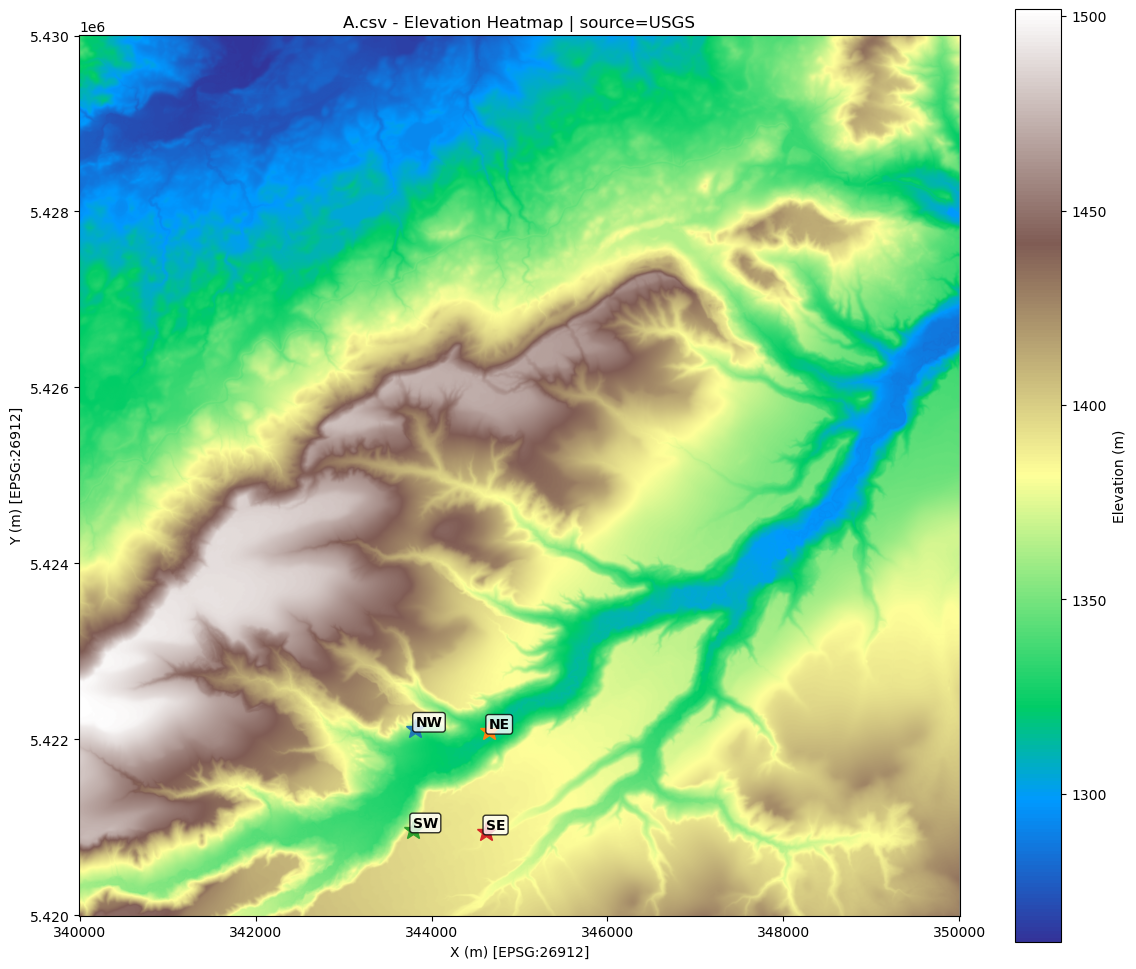

Saved: D:\Projects\BeaverBot\DEM\RumneyRanch\A_heatmap.png


In [20]:
# ============================================================
# Elevation heatmap (auto-detect + auto-align CRS)
#   - Reads large CSVs in chunks
#   - Auto-detects coordinate columns (meters or lon/lat)
#   - Ensures plotting is done in projected meters (preferred for DEM work)
#   - Optional: overlays corners (lon/lat or projected)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Optional: only needed if we must convert lon/lat -> projected meters
from pyproj import Transformer

# -------------------------------
# USER SETTINGS (safe defaults)
# -------------------------------
chunksize = 1_000_000
max_cells = 10_000_000          # cap the visualization grid to avoid RAM blowups
bin_size_m_default = 1.0        # start at 1m bins (native). will auto-coarsen if too many cells.




CORNERS_ARE_LONLAT = True


# -------------------------------
# Helper: detect columns
# -------------------------------
def pick_existing(cols, candidates):
    """Return first candidate that exists in cols (case-insensitive)."""
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

# Read a small header sample to detect column names/types
probe = pd.read_csv(csv_path, nrows=50, low_memory=False)
cols = list(probe.columns)

# Detect elevation column
elev_col = pick_existing(cols, ["elevation", "elev", "z", "dem", "height"])
if elev_col is None:
    # fall back: assume 3rd column is elevation (old style exports)
    elev_col = cols[2] if len(cols) >= 3 else None
if elev_col is None:
    raise RuntimeError("Could not detect elevation column. Add a column named 'elevation' (recommended).")

# Detect coordinate columns (prefer projected meters x/y, otherwise lon/lat)
x_col = pick_existing(cols, ["x", "x_m", "easting"])
y_col = pick_existing(cols, ["y", "y_m", "northing"])

lon_col = pick_existing(cols, ["lon", "longitude"])
lat_col = pick_existing(cols, ["lat", "latitude"])

if x_col and y_col:
    coord_mode = "projected_xy"
elif lon_col and lat_col:
    coord_mode = "lonlat"
else:
    # fallback: assume first two columns are coords
    # but we’ll decide if they’re lon/lat based on numeric ranges
    x_col = cols[0]
    y_col = cols[1]
    # inspect probe ranges to guess
    x_vals = pd.to_numeric(probe[x_col], errors="coerce")
    y_vals = pd.to_numeric(probe[y_col], errors="coerce")
    if (x_vals.abs().max() <= 180) and (y_vals.abs().max() <= 90):
        coord_mode = "lonlat_fallback"
        lon_col, lat_col = x_col, y_col
    else:
        coord_mode = "projected_xy_fallback"

print("=== CSV column detection ===")
print("  elevation:", elev_col)
print("  coord_mode:", coord_mode)
print("  x/y:", x_col, y_col)
print("  lon/lat:", lon_col, lat_col)

# Transformer if needed (lon/lat -> projected meters)
ll_to_xy = None
if coord_mode in ("lonlat", "lonlat_fallback"):
    ll_to_xy = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)

# Determine which columns to read each chunk
if coord_mode in ("projected_xy", "projected_xy_fallback"):
    usecols = [x_col, y_col, elev_col]
else:
    usecols = [lon_col, lat_col, elev_col]

# -------------------------------
# 1) First pass: extent (chunked) in projected meters
# -------------------------------
xmin, xmax = np.inf, -np.inf
ymin, ymax = np.inf, -np.inf

for chunk in pd.read_csv(csv_path, chunksize=chunksize, usecols=usecols, low_memory=False):
    a = chunk.copy()

    if coord_mode in ("projected_xy", "projected_xy_fallback"):
        a["x_m"] = pd.to_numeric(a[x_col], errors="coerce")
        a["y_m"] = pd.to_numeric(a[y_col], errors="coerce")
    else:
        lon = pd.to_numeric(a[lon_col], errors="coerce").to_numpy()
        lat = pd.to_numeric(a[lat_col], errors="coerce").to_numpy()
        good = np.isfinite(lon) & np.isfinite(lat)
        if not np.any(good):
            continue
        x_m, y_m = ll_to_xy.transform(lon[good], lat[good])
        a = a.loc[good].copy()
        a["x_m"] = x_m
        a["y_m"] = y_m

    a["elev"] = pd.to_numeric(a[elev_col], errors="coerce")
    a = a.dropna(subset=["x_m", "y_m", "elev"])
    if a.empty:
        continue

    xmin = min(xmin, float(a["x_m"].min()))
    xmax = max(xmax, float(a["x_m"].max()))
    ymin = min(ymin, float(a["y_m"].min()))
    ymax = max(ymax, float(a["y_m"].max()))

if not np.isfinite(xmin) or not np.isfinite(ymin):
    raise RuntimeError("Could not determine coordinate extent from CSV (all NaN after parsing).")

print("\n=== Extent used for plotting (meters) ===")
print(f"  x_m: {xmin:.3f} -> {xmax:.3f}")
print(f"  y_m: {ymin:.3f} -> {ymax:.3f}")

# -------------------------------
# 2) Choose bin size (meters) with safe cap
# -------------------------------
bin_size_m = float(bin_size_m_default)

def grid_dims(xmin, xmax, ymin, ymax, bs):
    ncols = int(np.ceil((xmax - xmin) / bs)) + 1
    nrows = int(np.ceil((ymax - ymin) / bs)) + 1
    return nrows, ncols

nrows, ncols = grid_dims(xmin, xmax, ymin, ymax, bin_size_m)
cells = nrows * ncols

if cells > max_cells:
    scale = np.sqrt(cells / max_cells)
    bin_size_m *= scale
    nrows, ncols = grid_dims(xmin, xmax, ymin, ymax, bin_size_m)
    cells = nrows * ncols

print(f"\nBinning heatmap at ~{bin_size_m:.3f} m")
print(f"Grid: {ncols} x {nrows} = {cells:,} cells")

sum_z = np.zeros(cells, dtype=np.float64)
cnt   = np.zeros(cells, dtype=np.uint32)

# -------------------------------
# 3) Second pass: accumulate mean elevation per bin (chunked)
# -------------------------------
for chunk in pd.read_csv(csv_path, chunksize=chunksize, usecols=usecols, low_memory=False):
    a = chunk.copy()

    if coord_mode in ("projected_xy", "projected_xy_fallback"):
        x_m = pd.to_numeric(a[x_col], errors="coerce").to_numpy()
        y_m = pd.to_numeric(a[y_col], errors="coerce").to_numpy()
        good = np.isfinite(x_m) & np.isfinite(y_m)
        if not np.any(good):
            continue
        x_m = x_m[good]
        y_m = y_m[good]
        z   = pd.to_numeric(a.loc[good, elev_col], errors="coerce").to_numpy()
    else:
        lon = pd.to_numeric(a[lon_col], errors="coerce").to_numpy()
        lat = pd.to_numeric(a[lat_col], errors="coerce").to_numpy()
        good = np.isfinite(lon) & np.isfinite(lat)
        if not np.any(good):
            continue
        x_m, y_m = ll_to_xy.transform(lon[good], lat[good])
        z = pd.to_numeric(a.loc[good, elev_col], errors="coerce").to_numpy()

    good2 = np.isfinite(z)
    if not np.any(good2):
        continue
    x_m = x_m[good2]
    y_m = y_m[good2]
    z   = z[good2]

    ix = ((x_m - xmin) / bin_size_m).astype(np.int64)
    iy = ((y_m - ymin) / bin_size_m).astype(np.int64)

    valid = (ix >= 0) & (ix < ncols) & (iy >= 0) & (iy < nrows)
    if not np.any(valid):
        continue

    idx = iy[valid] * ncols + ix[valid]
    np.add.at(sum_z, idx, z[valid])
    np.add.at(cnt,   idx, 1)

mean_z = np.full(cells, np.nan, dtype=np.float32)
mask = cnt > 0
mean_z[mask] = (sum_z[mask] / cnt[mask]).astype(np.float32)
Z = mean_z.reshape((nrows, ncols))

# -------------------------------
# 4) Plot heatmap in meters
# -------------------------------
xmax_plot = xmin + bin_size_m * (ncols - 1)
ymax_plot = ymin + bin_size_m * (nrows - 1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(
    Z,
    origin="lower",
    extent=[xmin, xmax_plot, ymin, ymax_plot],
    aspect="equal",
    cmap="terrain",
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Elevation (m)")

ax.set_xlabel(f"X (m) [EPSG:{DATA_EPSG}]")
ax.set_ylabel(f"Y (m) [EPSG:{DATA_EPSG}]")
ax.set_title(f"{Path(csv_path).name} - Elevation Heatmap | source={data_source}")

# -------------------------------
# 5) Optional: overlay corners (auto-convert if lon/lat)
# -------------------------------
if all(name in globals() for name in ["NW", "NE", "SW", "SE"]):
    if CORNERS_ARE_LONLAT:
        tf = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)
        NW_xy = tf.transform(*NW)
        NE_xy = tf.transform(*NE)
        SW_xy = tf.transform(*SW)
        SE_xy = tf.transform(*SE)
    else:
        NW_xy, NE_xy, SW_xy, SE_xy = NW, NE, SW, SE

    for (pt, label) in [(NW_xy, "NW"), (NE_xy, "NE"), (SW_xy, "SW"), (SE_xy, "SE")]:
        ax.plot(pt[0], pt[1], marker="*", markersize=14)
        ax.text(pt[0], pt[1], label, fontsize=10, weight="bold",
                ha="left", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8))
else:
    print("\n(no corners overlay — define NW/NE/SW/SE to plot them)")

plt.tight_layout()
plt.show()

out_png = os.path.join(os.path.dirname(csv_path), f"{Path(csv_path).stem}_heatmap.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved:", out_png)


In [21]:
DATA_EPSG

26912

In [22]:
# ============================================================
# Probe + column detection
#   - Works whether CSV has headers or not
#   - Works whether CSV has extra columns or not
#   - Sets: XCOL, YCOL, ZCOL, COORD_MODE
# ============================================================

import numpy as np
import pandas as pd

# ---- Read a probe safely ----
probe = pd.read_csv(csv_path, nrows=10000, low_memory=False, **read_kwargs)

print("\n=== PROBE: raw columns ===")
print(list(probe.columns))

# ---- Helpers ----
def _pick_col(cols, candidates):
    """Return first matching column name from candidates (case-insensitive)."""
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

cols = list(probe.columns)

# Prefer explicit names if present
ZCOL = _pick_col(cols, ["elevation", "elev", "z", "dem", "height"])
XCOL = _pick_col(cols, ["x", "x_m", "easting"])
YCOL = _pick_col(cols, ["y", "y_m", "northing"])

LONCOL = _pick_col(cols, ["lon", "longitude"])
LATCOL = _pick_col(cols, ["lat", "latitude"])

# Fallbacks if the file is unnamed / old-style 3-col export
if ZCOL is None and len(cols) >= 3:
    ZCOL = cols[2]
if XCOL is None and YCOL is None and len(cols) >= 2:
    # if we have lon/lat named, use them
    if LONCOL and LATCOL:
        XCOL, YCOL = LONCOL, LATCOL
    else:
        # last resort: assume first two columns are coordinates
        XCOL, YCOL = cols[0], cols[1]

# ---- Coerce numeric for probe ranges ----
p = probe[[XCOL, YCOL, ZCOL]].copy()
p[XCOL] = pd.to_numeric(p[XCOL], errors="coerce")
p[YCOL] = pd.to_numeric(p[YCOL], errors="coerce")
p[ZCOL] = pd.to_numeric(p[ZCOL], errors="coerce")
p = p.dropna(subset=[XCOL, YCOL, ZCOL])

if p.empty:
    raise RuntimeError(
        "All x/y/elevation are NaN after parsing. "
        "Check delimiter/header (read_kwargs), and confirm column names."
    )

x_min_probe, x_max_probe = float(p[XCOL].min()), float(p[XCOL].max())
y_min_probe, y_max_probe = float(p[YCOL].min()), float(p[YCOL].max())
z_min_probe, z_max_probe = float(p[ZCOL].min()), float(p[ZCOL].max())

# ---- Guess coordinate mode ----
# If coords fall into lon/lat ranges, treat as degrees
if (abs(x_min_probe) <= 180 and abs(x_max_probe) <= 180 and
    abs(y_min_probe) <= 90  and abs(y_max_probe) <= 90):
    COORD_MODE = "lonlat_degrees"
else:
    COORD_MODE = "projected_meters"

print("\n=== PROBE (numeric) ===")
print(f"Using columns: XCOL='{XCOL}', YCOL='{YCOL}', ZCOL='{ZCOL}'")
print(f"COORD_MODE: {COORD_MODE}")
print(f"x: {x_min_probe} -> {x_max_probe}")
print(f"y: {y_min_probe} -> {y_max_probe}")
print(f"elevation: {z_min_probe} -> {z_max_probe}")

# ---- Sparse-grid warning (important for pivot-based slope) ----
rows = len(p)
ux = p[XCOL].nunique()
uy = p[YCOL].nunique()
grid_cells = ux * uy
fill_ratio = rows / grid_cells if grid_cells else np.nan

print("\n=== GRID DIAGNOSTICS ===")
print(f"rows (probe): {rows:,}")
print(f"unique x: {ux:,}")
print(f"unique y: {uy:,}")
print(f"unique_x * unique_y: {grid_cells:,}")
print(f"fill ratio (rows / grid_cells): {fill_ratio:.6e}")

if np.isfinite(fill_ratio) and fill_ratio < 0.01:
    print("⚠️  WARNING: This looks like a SPARSE point set, not a full raster grid.")
    print("    Pivoting to a 2D grid (pivot_table/unstack) will explode in size.")
    print("    For slope, compute from the GeoTIFF raster and sample at points instead.")

print("=====================================\n")



=== PROBE: raw columns ===
['x_m', 'y_m', 'lon', 'lat', 'elevation']

=== PROBE (numeric) ===
Using columns: XCOL='x_m', YCOL='y_m', ZCOL='elevation'
COORD_MODE: projected_meters
x: 339994.4999707474 -> 340505.4999707474
y: 5429986.500015119 -> 5430005.500015119
elevation: 1305.0107 -> 1339.6714

=== GRID DIAGNOSTICS ===
rows (probe): 10,000
unique x: 512
unique y: 20
unique_x * unique_y: 10,240
fill ratio (rows / grid_cells): 9.765625e-01



In [23]:
# ============================================================
# STEP 1: Transform bbox lon/lat -> CSV CRS (DATA_EPSG)
# ============================================================
tf_ll_to_data = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)

ll_corners = np.array([NW, SW, SE, NE], dtype=float)
lon_c = ll_corners[:, 0]
lat_c = ll_corners[:, 1]
x_c, y_c = tf_ll_to_data.transform(lon_c, lat_c)

x_min_box, x_max_box = float(np.min(x_c)), float(np.max(x_c))
y_min_box, y_max_box = float(np.min(y_c)), float(np.max(y_c))


print("BBOX in CSV CRS:", x_min_box, x_max_box, y_min_box, y_max_box)

# If you see values near -112 and 48 here, you're still in degrees -> wrong
if abs(x_min_box) < 1000 and abs(x_max_box) < 1000:
    raise RuntimeError(
        "Your bbox is still in lon/lat degrees. "
        "Set DATA_EPSG to the CRS of the CSV x/y."
    )


print(f"=== STUDY AREA BBOX in CSV CRS (EPSG:{DATA_EPSG}) ===")
print(f"x_min: {x_min_box} | x_max: {x_max_box}")
print(f"y_min: {y_min_box} | y_max: {y_max_box}")
print("===============================================\n")



BBOX in CSV CRS: 343785.6015139786 344649.2431794735 5420946.072365532 5422114.128774194
=== STUDY AREA BBOX in CSV CRS (EPSG:26912) ===
x_min: 343785.6015139786 | x_max: 344649.2431794735
y_min: 5420946.072365532 | y_max: 5422114.128774194



In [24]:
print("BBOX (UTM):", x_min_box, x_max_box, y_min_box, y_max_box)
print("CSV probe x:", x_min_probe, x_max_probe, " | probe y:", y_min_probe, y_max_probe)
print("Note: probe y can be constant because it's the first scanline; that's normal.")


BBOX (UTM): 343785.6015139786 344649.2431794735 5420946.072365532 5422114.128774194
CSV probe x: 339994.4999707474 340505.4999707474  | probe y: 5429986.500015119 5430005.500015119
Note: probe y can be constant because it's the first scanline; that's normal.


In [25]:
DATA_EPSG

26912

In [26]:
# ============================================================
# STEP 1+2 (DROP-IN): Build bbox in CSV coordinates + stream-crop
#   - Handles CSVs with extra columns
#   - Handles lon/lat OR projected x/y
#   - Writes cropped CSV with columns: x, y, elevation
# ============================================================

import os
import numpy as np
import pandas as pd
from pyproj import Transformer



# ---- 0) Detect which columns are coordinates/elevation (robust) ----
probe = pd.read_csv(csv_path, nrows=1000, low_memory=False, **read_kwargs)
cols = list(probe.columns)

def pick_col(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

ZCOL = pick_col(cols, ["elevation", "elev", "z", "dem", "height"])
XCOL = pick_col(cols, ["x", "x_m", "easting"])
YCOL = pick_col(cols, ["y", "y_m", "northing"])
LONCOL = pick_col(cols, ["lon", "longitude"])
LATCOL = pick_col(cols, ["lat", "latitude"])

# Fallbacks (common 3-col exports)
if ZCOL is None and len(cols) >= 3:
    ZCOL = cols[2]
if (XCOL is None or YCOL is None) and LONCOL and LATCOL:
    XCOL, YCOL = LONCOL, LATCOL
if XCOL is None and YCOL is None and len(cols) >= 2:
    XCOL, YCOL = cols[0], cols[1]

# Numeric probe for coordinate-mode detection
p = probe[[XCOL, YCOL, ZCOL]].copy()
p[XCOL] = pd.to_numeric(p[XCOL], errors="coerce")
p[YCOL] = pd.to_numeric(p[YCOL], errors="coerce")
p[ZCOL] = pd.to_numeric(p[ZCOL], errors="coerce")
p = p.dropna(subset=[XCOL, YCOL, ZCOL])

if p.empty:
    raise RuntimeError("Probe parse failed: all x/y/elevation are NaN. Check read_kwargs delimiter/header.")

x_min_probe, x_max_probe = float(p[XCOL].min()), float(p[XCOL].max())
y_min_probe, y_max_probe = float(p[YCOL].min()), float(p[YCOL].max())

# If values look like lon/lat ranges, treat as degrees
if (abs(x_min_probe) <= 180 and abs(x_max_probe) <= 180 and
    abs(y_min_probe) <= 90  and abs(y_max_probe) <= 90):
    COORD_MODE = "lonlat_degrees"
else:
    COORD_MODE = "projected_meters"

print("\n=== COLUMN + COORD CHECK ===")
print(f"Using XCOL='{XCOL}', YCOL='{YCOL}', ZCOL='{ZCOL}'")
print(f"COORD_MODE: {COORD_MODE}")
print(f"CSV probe x: {x_min_probe} -> {x_max_probe}")
print(f"CSV probe y: {y_min_probe} -> {y_max_probe}")
print("================================\n")

# ---- 1) Build bbox in the SAME coords as the CSV ----
ll_corners = np.array([NW, SW, SE, NE], dtype=float)
lon_c = ll_corners[:, 0]
lat_c = ll_corners[:, 1]

if COORD_MODE == "lonlat_degrees":
    # CSV is already lon/lat
    x_min_box, x_max_box = float(np.min(lon_c)), float(np.max(lon_c))
    y_min_box, y_max_box = float(np.min(lat_c)), float(np.max(lat_c))
    print("BBOX will be used in lon/lat degrees (CSV is lon/lat).")
else:
    # CSV is projected; transform bbox lon/lat -> DATA_EPSG
    tf_ll_to_data = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)
    x_c, y_c = tf_ll_to_data.transform(lon_c, lat_c)
    x_min_box, x_max_box = float(np.min(x_c)), float(np.max(x_c))
    y_min_box, y_max_box = float(np.min(y_c)), float(np.max(y_c))
    print(f"BBOX transformed to projected CRS EPSG:{DATA_EPSG} (CSV is projected).")

print("\n=== BBOX IN CSV COORDS ===")
print(f"x_min_box: {x_min_box} | x_max_box: {x_max_box}")
print(f"y_min_box: {y_min_box} | y_max_box: {y_max_box}")
print("==========================\n")

# ---- 2) Stream + crop (chunked) ----
base = os.path.splitext(file_name)[0]
cropped_path = os.path.join(path, f"{base}_cropped.csv")

if os.path.exists(cropped_path):
    os.remove(cropped_path)
    print("Removed existing cropped file:", cropped_path)

chunksize = 1_000_000
first = True
total_rows = 0
total_kept = 0

# If you know your nodata from the tif, set it here; otherwise leave as None
NODATA = -999999  # change to None if not applicable

for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize, low_memory=False, **read_kwargs), start=1):
    total_rows += len(chunk)

    # Select the correct columns FIRST (works even if CSV has 5+ columns)
    chunk = chunk[[XCOL, YCOL, ZCOL]].copy()
    chunk.columns = ["x", "y", "elevation"]  # standardize downstream

    # Coerce numeric
    chunk["x"] = pd.to_numeric(chunk["x"], errors="coerce")
    chunk["y"] = pd.to_numeric(chunk["y"], errors="coerce")
    chunk["elevation"] = pd.to_numeric(chunk["elevation"], errors="coerce")
    chunk = chunk.dropna(subset=["x", "y", "elevation"])

    # Filter nodata if applicable
    if NODATA is not None:
        chunk = chunk[chunk["elevation"] != NODATA]

    # Crop mask in CSV coordinates
    mask = (
        (chunk["x"] >= x_min_box) & (chunk["x"] <= x_max_box) &
        (chunk["y"] >= y_min_box) & (chunk["y"] <= y_max_box)
    )
    cropped = chunk.loc[mask]

    print(f"Chunk {i}: read {len(chunk):,} | kept {len(cropped):,}")

    if not cropped.empty:
        cropped.to_csv(cropped_path, mode="a", index=False, header=first)
        first = False
        total_kept += len(cropped)

print("\n=== STREAMING COMPLETE ===")
print(f"Total rows read : {total_rows:,}")
print(f"Total rows kept : {total_kept:,}")
print("Cropped file at :", cropped_path)

if total_kept == 0:
    raise RuntimeError(
        "No rows fell inside bbox.\n"
        f"- BBOX x: {x_min_box}..{x_max_box} | y: {y_min_box}..{y_max_box}\n"
        f"- PROBE x: {x_min_probe}..{x_max_probe} | y: {y_min_probe}..{y_max_probe}\n"
        "Likely causes:\n"
        "  (1) bbox corners are wrong, or\n"
        "  (2) DATA_EPSG is wrong, or\n"
        "  (3) CSV coords are lon/lat but you assumed projected (or vice versa).\n"
    )



=== COLUMN + COORD CHECK ===
Using XCOL='x_m', YCOL='y_m', ZCOL='elevation'
COORD_MODE: projected_meters
CSV probe x: 339994.4999707474 -> 340505.4999707474
CSV probe y: 5430004.500015119 -> 5430005.500015119

BBOX transformed to projected CRS EPSG:26912 (CSV is projected).

=== BBOX IN CSV COORDS ===
x_min_box: 343785.6015139786 | x_max_box: 344649.2431794735
y_min_box: 5420946.072365532 | y_max_box: 5422114.128774194

Removed existing cropped file: D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped.csv
Chunk 1: read 1,000,000 | kept 0
Chunk 2: read 1,000,000 | kept 0
Chunk 3: read 1,000,000 | kept 0
Chunk 4: read 1,000,000 | kept 0
Chunk 5: read 1,000,000 | kept 0
Chunk 6: read 1,000,000 | kept 0
Chunk 7: read 1,000,000 | kept 0
Chunk 8: read 1,000,000 | kept 0
Chunk 9: read 1,000,000 | kept 0
Chunk 10: read 1,000,000 | kept 0
Chunk 11: read 1,000,000 | kept 0
Chunk 12: read 1,000,000 | kept 0
Chunk 13: read 1,000,000 | kept 0
Chunk 14: read 1,000,000 | kept 0
Chunk 15: read 1,000,000 

Cropped data: 1,007,984 rows
X range: 343786.499971 to 344648.499971
Y range: 5420946.500015 to 5422113.500015
Detected CSV coordinates: projected meters (assumed EPSG:26912).

Binning at 1.000 m
Grid: 863 x 1168 = 1,007,984 cells

Saved cropped elevation plot to: D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped_elevation_heatmap_cropped_projected.png


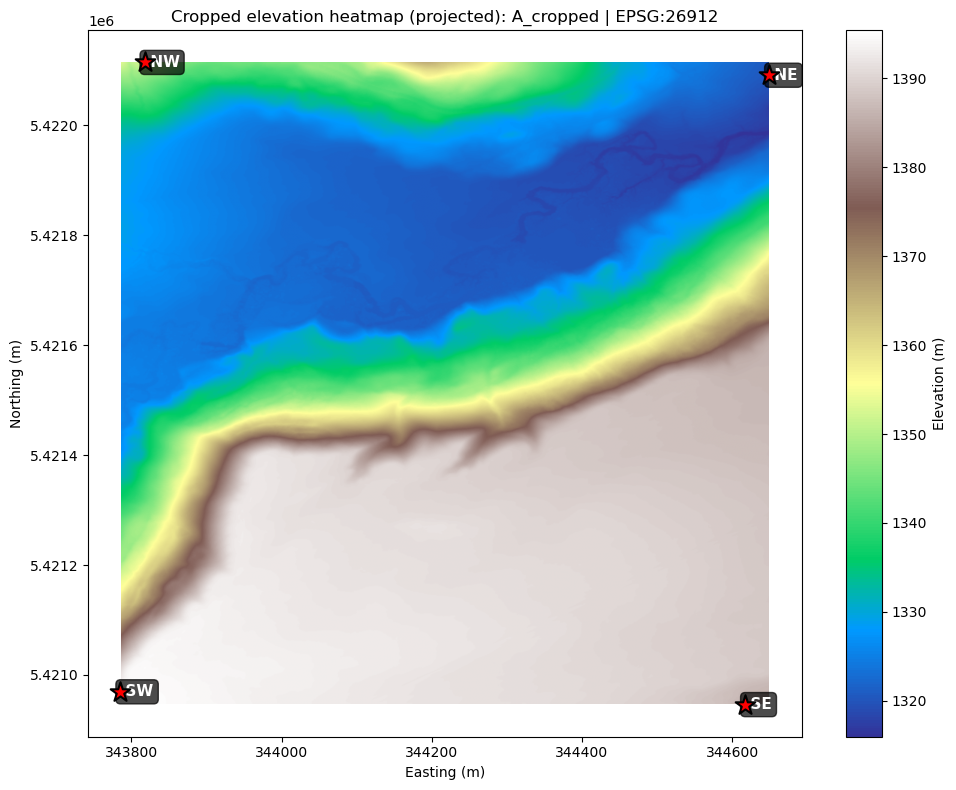

In [27]:
# ============================================================
# STEP 3 (DROP-IN): Quick plot of cropped data (1m binning)
#   - Robust to CSV being lon/lat OR projected meters
#   - Always plots in projected CRS (EPSG:DATA_EPSG) so 1m stays 1m
#   - Overlays NW/SW/SE/NE corners after transforming to the same CRS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from pathlib import Path

# ---- Load cropped data ----
design_area = pd.read_csv(cropped_path, low_memory=False)

# Keep only needed cols (but don’t crash if extra cols exist)
need = ["x", "y", "elevation"]
missing = [c for c in need if c not in design_area.columns]
if missing:
    raise RuntimeError(f"cropped CSV must contain columns {need}. Missing: {missing}")

design_area = design_area[need].copy()
for c in need:
    design_area[c] = pd.to_numeric(design_area[c], errors="coerce")
design_area = design_area.dropna(subset=need)

print(f"Cropped data: {len(design_area):,} rows")
print(f"X range: {design_area['x'].min():.6f} to {design_area['x'].max():.6f}")
print(f"Y range: {design_area['y'].min():.6f} to {design_area['y'].max():.6f}")

# ---- Detect whether CSV x/y are degrees or meters ----
xmn, xmx = float(design_area["x"].min()), float(design_area["x"].max())
ymn, ymx = float(design_area["y"].min()), float(design_area["y"].max())

is_lonlat = (abs(xmn) <= 180 and abs(xmx) <= 180 and abs(ymn) <= 90 and abs(ymx) <= 90)

if is_lonlat:
    print("Detected CSV coordinates: lon/lat degrees -> projecting to meters for plotting/binning.")
    tf_to_m = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)
    xm, ym = tf_to_m.transform(design_area["x"].to_numpy(), design_area["y"].to_numpy())
    X = np.asarray(xm, dtype=np.float64)
    Y = np.asarray(ym, dtype=np.float64)
else:
    print(f"Detected CSV coordinates: projected meters (assumed EPSG:{DATA_EPSG}).")
    X = design_area["x"].to_numpy(np.float64)
    Y = design_area["y"].to_numpy(np.float64)

Zvals = design_area["elevation"].to_numpy(np.float64)

# ---- Bin at 1m (or coarsen if too many cells) ----
bin_size_m = 1.0          # <-- this matches your 1 m/pixel GeoTIFF
max_cells  = 10_000_000   # safety cap

xmin, xmax = float(np.min(X)), float(np.max(X))
ymin, ymax = float(np.min(Y)), float(np.max(Y))

def grid_dims(xmin, xmax, ymin, ymax, bs):
    ncols = int(np.ceil((xmax - xmin) / bs)) + 1
    nrows = int(np.ceil((ymax - ymin) / bs)) + 1
    return nrows, ncols

nrows, ncols = grid_dims(xmin, xmax, ymin, ymax, bin_size_m)
cells = nrows * ncols

if cells > max_cells:
    scale = np.sqrt(cells / max_cells)
    bin_size_m *= scale
    nrows, ncols = grid_dims(xmin, xmax, ymin, ymax, bin_size_m)
    cells = nrows * ncols

print(f"\nBinning at {bin_size_m:.3f} m")
print(f"Grid: {ncols} x {nrows} = {cells:,} cells\n")

sum_z = np.zeros(cells, dtype=np.float64)
cnt   = np.zeros(cells, dtype=np.uint32)

ix = ((X - xmin) / bin_size_m).astype(np.int64)
iy = ((Y - ymin) / bin_size_m).astype(np.int64)

valid = (ix >= 0) & (ix < ncols) & (iy >= 0) & (iy < nrows)
idx = iy[valid] * ncols + ix[valid]

np.add.at(sum_z, idx, Zvals[valid])
np.add.at(cnt,   idx, 1)

mean_z = np.full(cells, np.nan, dtype=np.float32)
m = cnt > 0
mean_z[m] = (sum_z[m] / cnt[m]).astype(np.float32)
Zgrid = mean_z.reshape((nrows, ncols))

# ---- Project corner points to meters for overlay ----
tf_ll_to_m = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)

corner_points_ll = {"NW": NW, "SW": SW, "SE": SE, "NE": NE}
corner_xy = {}
for name, (lon, lat) in corner_points_ll.items():
    cx, cy = tf_ll_to_m.transform(lon, lat)
    corner_xy[name] = (cx, cy)

# ---- Plot ----
xmax_plot = xmin + bin_size_m * (ncols - 1)
ymax_plot = ymin + bin_size_m * (nrows - 1)

plt.figure(figsize=(10, 8))
plt.imshow(
    Zgrid,
    origin="lower",
    extent=[xmin, xmax_plot, ymin, ymax_plot],
    cmap="terrain",
    aspect="auto"
)
plt.colorbar(label="Elevation (m)")

for name, (cx, cy) in corner_xy.items():
    plt.scatter(cx, cy, marker="*", s=220, color="red",
                edgecolors="black", linewidths=1.5, zorder=5)
    plt.text(cx, cy, f" {name}", fontsize=11, weight="bold", va="center", color="white",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7))

title_base = Path(cropped_path).stem
plt.title(f"Cropped elevation heatmap (projected): {title_base} | EPSG:{DATA_EPSG}")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()

plot_path = os.path.join(path, f"{title_base}_elevation_heatmap_cropped_projected.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
print("Saved cropped elevation plot to:", plot_path)
plt.show()


# Convert CSV file to ASC file

In [28]:
csv_path = cropped_path
out_asc_path = os.path.join(path, f"{base}.asc")

In [29]:
csv_path

'D:\\Projects\\BeaverBot\\DEM\\RumneyRanch\\A_cropped.csv'

In [30]:


def _infer_cellsize(x, y):
    #Robust cellsize guess from median unique diffs; fallback to span/500.
    xu = np.unique(np.sort(x))
    yu = np.unique(np.sort(y))
    ests = []
    if len(xu) > 1: ests.append(np.median(np.diff(xu)))
    if len(yu) > 1: ests.append(np.median(np.diff(yu)))
    if ests:
        # Avoid weird huge steps if there are occasional large gaps
        return float(np.nanmin(ests))
    span = max(x.max()-x.min(), y.max()-y.min())
    return float(span / 500.0 if span > 0 else 1.0)

def _grid_axes(x, y, cellsize, buffer_cells=0):
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())
    x_min -= buffer_cells * cellsize
    y_min -= buffer_cells * cellsize
    x_max += buffer_cells * cellsize
    y_max += buffer_cells * cellsize
    xg = np.arange(x_min, x_max + 0.5*cellsize, cellsize)
    yg = np.arange(y_min, y_max + 0.5*cellsize, cellsize)
    return xg, yg

def _interpolate_idw(x, y, z, Xg, Yg, k=12, power=2.0, nodata=np.nan):
    #Fast IDW via KD-tree (k nearest)
    pts = np.column_stack([x, y])
    tree = cKDTree(pts)
    q = np.column_stack([Xg.ravel(), Yg.ravel()])
    dists, idxs = tree.query(q, k=min(k, len(pts)))
    # Ensure 2D
    if dists.ndim == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]
    weights = 1.0 / np.maximum(dists, 1e-12)**power
    z_neighbors = z[idxs]
    z_num = np.sum(weights * z_neighbors, axis=1)
    z_den = np.sum(weights, axis=1)
    Zi = z_num / np.maximum(z_den, 1e-12)
    Zi = Zi.reshape(Xg.shape)
    # If all neighbors are identical NaNs (shouldn't happen), set nodata
    Zi[~np.isfinite(Zi)] = nodata
    return Zi

def xyz_csv_to_asc_interpolated(csv_path, out_asc_path,
                                x_col="x", y_col="y", z_col="elevation",
                                cellsize=None,
                                method="nearest",   # 'nearest'|'linear'|'cubic'|'idw'
                                idw_k=12, idw_power=2.0,
                                buffer_cells=0,
                                nodata=-9999,
                                round_decimals=9):
    """
    #Create an interpolated ESRI ASCII grid from scattered XYZ points.
    """
    df = pd.read_csv(csv_path)
    # Clean/round to reduce jitter
    df = df[[x_col, y_col, z_col]].dropna()
    df[x_col] = df[x_col].round(round_decimals)
    df[y_col] = df[y_col].round(round_decimals)

    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    z = df[z_col].to_numpy(dtype=float)

    if cellsize is None:
        cellsize = _infer_cellsize(x, y)

    xg, yg = _grid_axes(x, y, cellsize, buffer_cells=buffer_cells)
    Xg, Yg = np.meshgrid(xg, yg)

    # Interpolate
    if method.lower() == "idw":
        Zg = _interpolate_idw(x, y, z, Xg, Yg, k=idw_k, power=idw_power, nodata=np.nan)
    else:
        Zg = griddata(points=np.column_stack([x, y]),
                      values=z,
                      xi=(Xg, Yg),
                      method=method.lower())

    # Replace NaNs (uninterpolated) with NODATA
    Zg = np.where(np.isnan(Zg), nodata, Zg)

    # ESRI ASCII expects rows written from maxY -> minY
    Z_top_to_bottom = np.flipud(Zg)

    nrows, ncols = Zg.shape
    xllcorner = float(xg.min())
    yllcorner = float(yg.min())

    with open(out_asc_path, "w") as f:
        f.write(f"ncols         {ncols}\n")
        f.write(f"nrows         {nrows}\n")
        f.write(f"xllcorner     {xllcorner}\n")
        f.write(f"yllcorner     {yllcorner}\n")
        f.write(f"cellsize      {cellsize}\n")
        f.write(f"NODATA_value  {nodata}\n")
        for i in range(nrows):
            row = Z_top_to_bottom[i, :]
            f.write(" ".join(str(float(v)) for v in row) + "\n")

    print(f"✓ Wrote {out_asc_path}  "
          f"({ncols}x{nrows}, cellsize={cellsize}, method={method})")


xyz_csv_to_asc_interpolated(csv_path, out_asc_path)

✓ Wrote D:\Projects\BeaverBot\DEM\RumneyRanch\A.asc  (863x1168, cellsize=1.0, method=nearest)


# Hydromodeling

In [31]:
def create_grid_FIXED(
    df: pd.DataFrame,
    grid_spacing: float = 1.0,
    x_col: str = "x",
    y_col: str = "y",
    value_cols=("elevation",),   # add more like ("elevation","width_m","depth_m")
    agg: str = "first",          # or "mean", "max", etc. if multiple points fall in one cell
    return_df_with_indices: bool = True
):
    """
    Build a rectilinear grid from scattered x,y points in `df`.
    - Snaps coordinates to the specified `grid_spacing`
    - Returns 2D arrays for each column in `value_cols`
    - Preserves Y increasing upward (origin='lower' for imshow)

    Returns:
        grid = {
            "x_coords": np.ndarray [nx],
            "y_coords": np.ndarray [ny],
            "X": np.ndarray [ny, nx],
            "Y": np.ndarray [ny, nx],
            "<col>": np.ndarray [ny, nx] for each col in value_cols,
            "mask": np.ndarray [ny, nx]  # True where at least one value exists
            "x_to_ix": dict, "y_to_iy": dict
        }
        (and optionally a copy of df with snapped coords + ix/iy)
    """
    if df.empty:
        raise ValueError("Input DataFrame is empty.")

    # 1) snap coordinates to grid
    def _snap(v, s):
        return np.round(np.asarray(v, dtype=float) / s) * s

    x_snap = _snap(df[x_col].values, grid_spacing)
    y_snap = _snap(df[y_col].values, grid_spacing)

    # 2) coordinate axes
    x_coords = np.unique(x_snap)
    y_coords = np.unique(y_snap)
    nx, ny = len(x_coords), len(y_coords)

    # 3) index maps
    x_to_ix = {x: i for i, x in enumerate(x_coords)}
    y_to_iy = {y: i for i, y in enumerate(y_coords)}

    # 4) pivot each requested value column onto the full grid
    #    Use full reindex so missing cells become NaN
    grid = {
        "x_coords": x_coords,
        "y_coords": y_coords,
        "x_to_ix": x_to_ix,
        "y_to_iy": y_to_iy,
    }

    # Small helper to create a uniform 2D mesh (useful for plotting)
    X, Y = np.meshgrid(x_coords, y_coords)
    grid["X"], grid["Y"] = X, Y

    # Temporary working frame with snapped coords
    work = df.copy()
    work["_x_snap"] = x_snap
    work["_y_snap"] = y_snap

    # If label-like columns exist that are non-numeric, you can still pivot them with agg='first'
    for col in value_cols:
        if col not in work.columns:
            # create a placeholder if missing
            grid[col] = np.full((ny, nx), np.nan, dtype=float)
            continue

        # Choose dtype-aware aggregation; pandas pivot_table will handle strings too with 'first'
        pv = (
            work.pivot_table(
                index="_y_snap",
                columns="_x_snap",
                values=col,
                aggfunc=agg,
                dropna=False,
            )
            .reindex(index=y_coords, columns=x_coords)
        )

        # Convert to array; for non-numeric (e.g., 'label') keep object dtype
        arr = pv.values
        grid[col] = arr

    # 5) presence mask: any non-NaN among numeric columns (fall back to all columns)
    cand_cols = [c for c in value_cols if np.issubdtype(np.asarray(grid[c]).dtype, np.number)]
    if not cand_cols:
        # if all are non-numeric, fall back to existence in the df
        presence = ~pd.isna(
            work.pivot_table(index="_y_snap", columns="_x_snap", values=value_cols[0], aggfunc="first")
             .reindex(index=y_coords, columns=x_coords)
             .values
        )
    else:
        stacks = [np.asarray(grid[c]) for c in cand_cols]
        presence = np.any(~np.isnan(stacks), axis=0) if len(stacks) > 1 else ~np.isnan(stacks[0])
    grid["mask"] = presence

    # 6) (optional) annotate df with snapped coords and grid indices
    if return_df_with_indices:
        work["ix"] = [x_to_ix[x] for x in work["_x_snap"]]
        work["iy"] = [y_to_iy[y] for y in work["_y_snap"]]
        return grid, work.drop(columns=["_x_snap", "_y_snap"])

    return grid

Loading cropped data...
Loaded 1,007,984 points
Detected projected CSV (assumed EPSG:26912)
Estimated grid spacing: 1.000 m (x_step=1.0, y_step=1.0)
Grid: 1168 rows x 863 cols = 1,007,984 nodes
NaNs in Z grid: 0 / 1,007,984
Running FlowAccumulator...
Done.
Drainage area (m²): min= 0.0 max= 687121.0 mean= 671.3906649311893


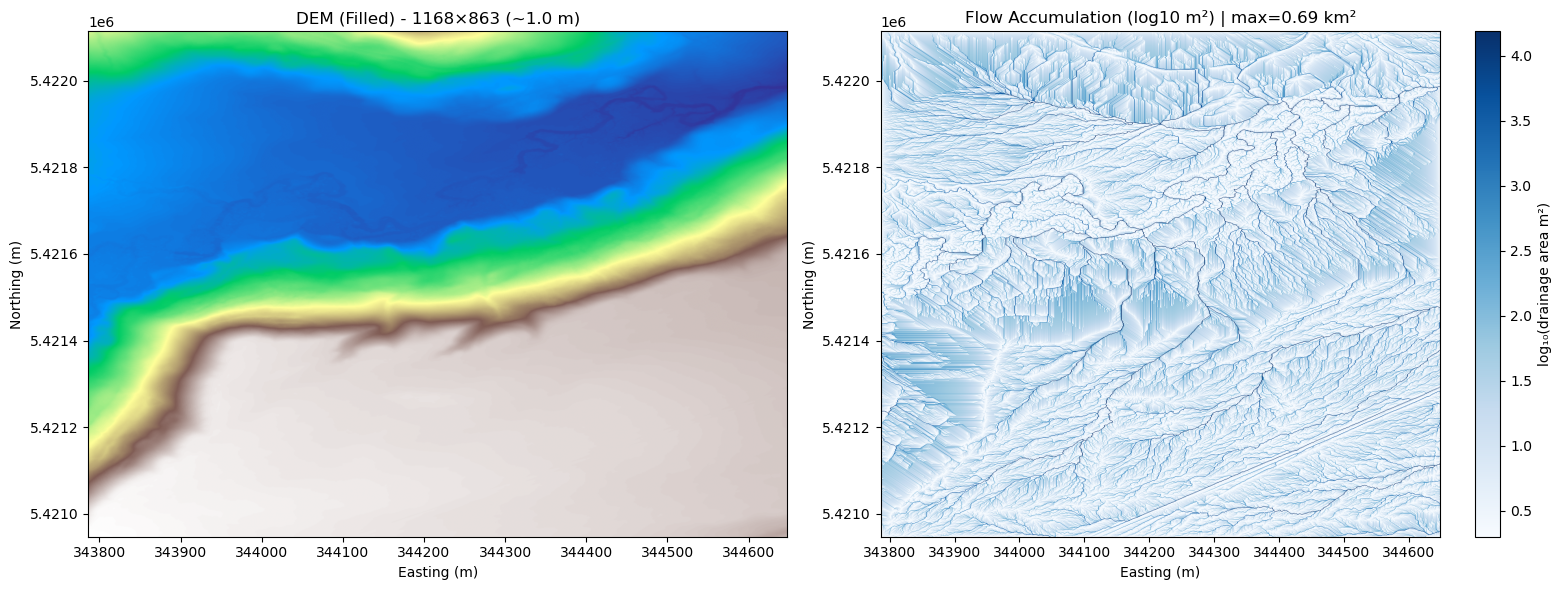

In [32]:

# ============================================================================
# STEP 2+3 (DROP-IN): Build grid in METERS, run flow accumulation, plot
# ============================================================================

print("Loading cropped data...")
df = pd.read_csv(cropped_path, low_memory=False).copy()
df = df.iloc[:, :3].copy()
df.columns = ["x", "y", "elevation"]

for c in ["x", "y", "elevation"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["x", "y", "elevation"])
print(f"Loaded {len(df):,} points")

# ---- Detect lon/lat vs projected meters ----
xmn, xmx = float(df["x"].min()), float(df["x"].max())
ymn, ymx = float(df["y"].min()), float(df["y"].max())
is_lonlat = (abs(xmn) <= 180 and abs(xmx) <= 180 and abs(ymn) <= 90 and abs(ymx) <= 90)

if is_lonlat:
    print("Detected lon/lat CSV -> projecting to EPSG:", DATA_EPSG)
    tf = Transformer.from_crs("EPSG:4326", f"EPSG:{DATA_EPSG}", always_xy=True)
    X, Y = tf.transform(df["x"].to_numpy(), df["y"].to_numpy())
    df["x"] = X
    df["y"] = Y
else:
    print(f"Detected projected CSV (assumed EPSG:{DATA_EPSG})")

# ---- Infer grid spacing in meters (should be ~1.0 for your GeoTIFF) ----
def infer_step(vals):
    u = np.unique(np.round(vals.astype(float), 6))
    u.sort()
    d = np.diff(u)
    d = d[d > 0]
    if d.size == 0:
        return np.nan
    # mode-ish (most common)
    r = np.round(d, 6)
    uniq, cnt = np.unique(r, return_counts=True)
    return float(uniq[np.argmax(cnt)])

dx_x = infer_step(df["x"].values)
dx_y = infer_step(df["y"].values)
grid_spacing_m = np.nanmin([dx_x, dx_y])
if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
    grid_spacing_m = 1.0

print(f"Estimated grid spacing: {grid_spacing_m:.3f} m (x_step={dx_x}, y_step={dx_y})")

# ---- Build snapped grid (meters) ----
grid_dict, df_with_ixiy = create_grid_FIXED(
    df,
    grid_spacing=grid_spacing_m,
    value_cols=("elevation",),
    agg="mean",
)

x_coords = grid_dict["x_coords"]
y_coords = grid_dict["y_coords"]
nrows, ncols = len(y_coords), len(x_coords)
print(f"Grid: {nrows} rows x {ncols} cols = {nrows*ncols:,} nodes")

if nrows < 4 or ncols < 4:
    raise ValueError(f"Grid too small ({nrows}x{ncols}). Check cropping / spacing.")

# ---- Create Landlab grid in METERS ----
try:
    mg = RasterModelGrid((nrows, ncols), xy_spacing=grid_spacing_m)
except TypeError:
    mg = RasterModelGrid((nrows, ncols), grid_spacing_m)

Z2d = np.asarray(grid_dict["elevation"], dtype=float)
nan_mask = ~np.isfinite(Z2d)
print(f"NaNs in Z grid: {nan_mask.sum():,} / {Z2d.size:,}")

# Close and fill NaNs (holes) safely
if nan_mask.any():
    mg.status_at_node[nan_mask.ravel(order="C")] = mg.BC_NODE_IS_CLOSED
    safe_min = np.nanmin(Z2d)
    Z2d = np.where(nan_mask, safe_min, Z2d)

mg.add_field("topographic__elevation", Z2d.ravel(order="C"), at="node", clobber=True)

# Open boundaries (water can leave domain)
mg.set_closed_boundaries_at_grid_edges(False, False, False, False)

# ---- Run flow accumulation ----
print("Running FlowAccumulator...")
fa = FlowAccumulator(mg, flow_director="D8", depression_finder="DepressionFinderAndRouter")
fa.run_one_step()

drainage_area_m2 = mg.at_node["drainage_area"].copy()  # <-- already in m² because dx is meters
print("Done.")
print("Drainage area (m²):",
      "min=", np.nanmin(drainage_area_m2),
      "max=", np.nanmax(drainage_area_m2),
      "mean=", np.nanmean(drainage_area_m2))

# ---- Plot (use robust scaling so you don't get “all one color”) ----
da2d = drainage_area_m2.reshape((nrows, ncols))
closed2d = (mg.status_at_node.reshape((nrows, ncols)) == mg.BC_NODE_IS_CLOSED)
da2d = np.where(closed2d, np.nan, da2d)

# log scale that won’t blow up / flatten (add one cell area)
cell_area = grid_spacing_m * grid_spacing_m
log_da = np.log10(da2d + cell_area)

# percentile stretch
vmin, vmax = np.nanpercentile(log_da, [5, 99.5])

xmin, xmax = float(x_coords.min()), float(x_coords.max())
ymin, ymax = float(y_coords.min()), float(y_coords.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DEM
axes[0].imshow(
    Z2d, origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    cmap="terrain", aspect="auto"
)
axes[0].set_title(f"DEM (Filled) - {nrows}×{ncols} (~{grid_spacing_m:.1f} m)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

# Flow accumulation
im = axes[1].imshow(
    log_da, origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    cmap="Blues", aspect="auto",
    vmin=vmin, vmax=vmax
)
axes[1].set_title(f"Flow Accumulation (log10 m²) | max={np.nanmax(da2d)/1e6:.2f} km²")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
plt.colorbar(im, ax=axes[1], label="log₁₀(drainage area m²)")

plt.tight_layout()
plt.show()

In [33]:


# ============================================================================
# STEP 4: Map drainage area back to CSV and save
# ============================================================================

print("\nMapping drainage area back to original points...")

# Reshape drainage_area back to 2D grid
da2d = drainage_area_m2.reshape((nrows, ncols))

# Use the df_with_ixiy dataframe (which has ix, iy grid indices)
# to look up the corresponding drainage area for each point
df_with_ixiy["drainage_area_m2"] = [
    da2d[iy, ix] if (0 <= iy < nrows and 0 <= ix < ncols) else np.nan
    for ix, iy in zip(df_with_ixiy["ix"], df_with_ixiy["iy"])
]

# Optional: also add drainage area in km² for easier interpretation
df_with_ixiy["drainage_area_km2"] = df_with_ixiy["drainage_area_m2"] / 1e6

print(f"Added drainage area to {len(df_with_ixiy):,} points")
print(f"  Range: {df_with_ixiy['drainage_area_km2'].min():.6f} to {df_with_ixiy['drainage_area_km2'].max():.2f} km²")


# If you want to update the original cropped file instead:
df_with_ixiy.to_csv(cropped_path, index=False)
print(f"\nUpdated: {cropped_path}")


Mapping drainage area back to original points...
Added drainage area to 1,007,984 points
  Range: 0.000000 to 0.69 km²

Updated: D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped.csv



Loading drainage area data from: D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped.csv
Loaded: 1,007,984 rows
Grid: 1168 rows × 863 cols
Spacing: dx≈1.000 m, dy≈1.000 m
Drainage area range: 0.000000 to 0.69 km²
Saved heatmap to: D:\Projects\BeaverBot\DEM\RumneyRanch\A_drainage_heatmap.png


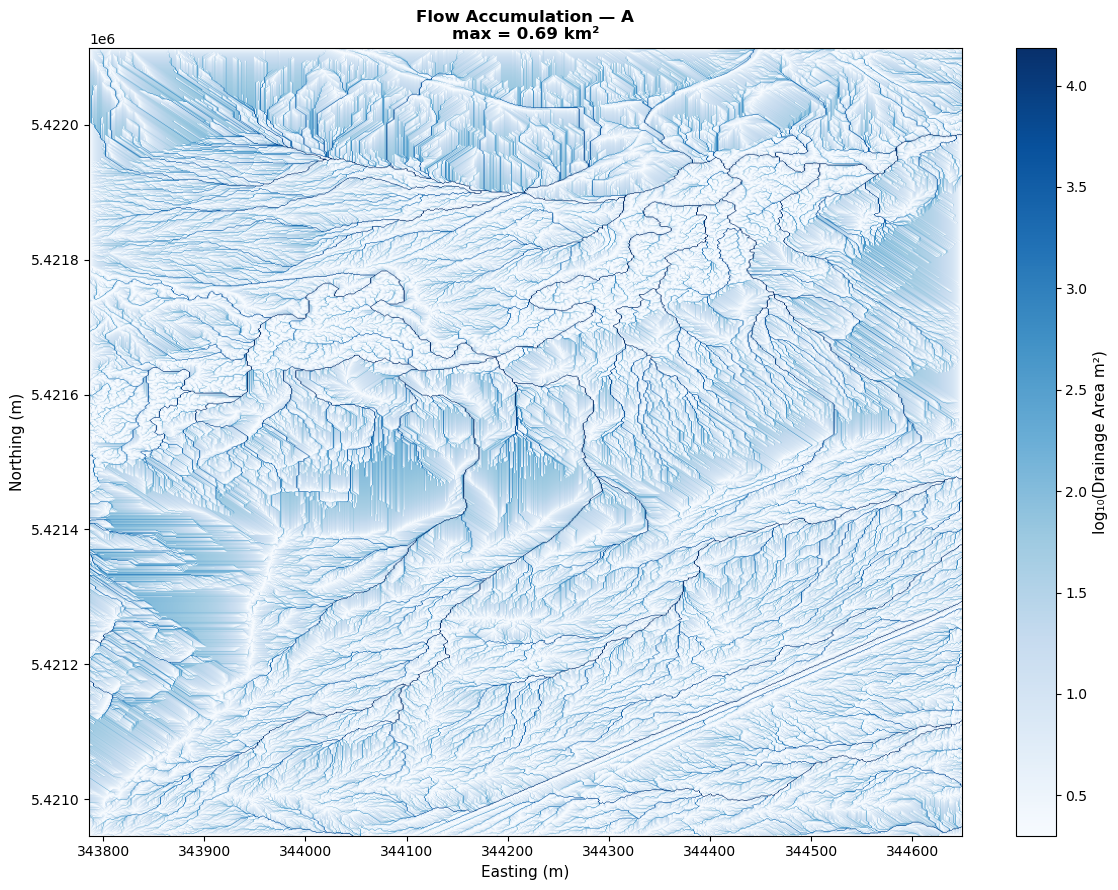

In [34]:
# ====================================
# Visualize Flow Accumulation (Drainage Area)
# ====================================
ext = ".csv"
png = ".png"
drainage_file = f"{base}_cropped{ext}"  # Updated filename
heat_file = f"{base}_drainage_heatmap{png}"
csv_path = os.path.join(path, drainage_file)
plot_heatmap_path = os.path.join(path, heat_file)

print(f"\nLoading drainage area data from: {csv_path}")

# ----------------------------
# Load + clean
# ----------------------------
df = pd.read_csv(csv_path, low_memory=False)

# Check for required columns
needed = ["x", "y", "drainage_area_m2"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing columns: {missing}\nFound columns: {list(df.columns)}")

df = df[["x", "y", "drainage_area_m2", "drainage_area_km2"]].copy()
df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["drainage_area_m2"] = pd.to_numeric(df["drainage_area_m2"], errors="coerce")
df["drainage_area_km2"] = pd.to_numeric(df["drainage_area_km2"], errors="coerce")
df = df.dropna(subset=["x", "y", "drainage_area_m2"])

print(f"Loaded: {len(df):,} rows")

# ----------------------------
# Infer grid spacing (meters)
# ----------------------------
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())

if len(xs) < 2 or len(ys) < 2:
    raise ValueError("Not enough unique x/y values to form a grid.")

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))
x0, y0 = xs[0], ys[0]
nx, ny = len(xs), len(ys)

print(f"Grid: {ny} rows × {nx} cols")
print(f"Spacing: dx≈{dx:.3f} m, dy≈{dy:.3f} m")

# ----------------------------
# Map points to grid indices + aggregate
# ----------------------------
ix = np.rint((df["x"].to_numpy() - x0) / dx).astype(np.int64)
iy = np.rint((df["y"].to_numpy() - y0) / dy).astype(np.int64)
da = df["drainage_area_m2"].to_numpy(dtype=np.float64)

valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(da)
ix, iy, da = ix[valid], iy[valid], da[valid]

# Aggregate (mean if multiple points per cell)
sum_da = np.zeros((ny, nx), dtype=np.float64)
cnt_da = np.zeros((ny, nx), dtype=np.uint32)
np.add.at(sum_da, (iy, ix), da)
np.add.at(cnt_da, (iy, ix), 1)

DA = np.full((ny, nx), np.nan, dtype=np.float64)
mask = cnt_da > 0
DA[mask] = sum_da[mask] / cnt_da[mask]

print(f"Drainage area range: {np.nanmin(DA)/1e6:.6f} to {np.nanmax(DA)/1e6:.2f} km²")

# ----------------------------
# Plot with log scale for better visualization
# ----------------------------
extent = [xs.min() - dx/2, xs.max() + dx/2, ys.min() - dy/2, ys.max() + dy/2]

# Log scale (add small constant to avoid log(0))
cell_area = dx * dy
log_DA = np.log10(DA + cell_area)

# Robust color scaling (5th to 99.5th percentile)
vmin, vmax = np.nanpercentile(log_DA, [5, 99.5])

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(
    log_DA, 
    origin="lower", 
    extent=extent, 
    aspect="auto",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log₁₀(Drainage Area m²)", fontsize=11)

ax.set_xlabel("Easting (m)", fontsize=11)
ax.set_ylabel("Northing (m)", fontsize=11)
ax.set_title(
    f"Flow Accumulation — {base}\nmax = {np.nanmax(DA)/1e6:.2f} km²", 
    fontsize=12, 
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(plot_heatmap_path, dpi=200, bbox_inches='tight')
print(f"Saved heatmap to: {plot_heatmap_path}")
plt.show()

In [35]:
# ============================================================================
# STEP 4: Extract Drainage
# ============================================================================

threshold_percentile = 0.1 # Adjust 0.1-99.9 as needed
threshold = np.percentile(drainage_area_m2, threshold_percentile)
stream_mask = drainage_area_m2 >= threshold

print(f"\nStream extraction:")
print(f"  Threshold: {threshold:.2f} m² ({threshold_percentile}th percentile)")
print(f"  Stream cells: {stream_mask.sum():,}")


Stream extraction:
  Threshold: 0.00 m² (0.1th percentile)
  Stream cells: 1,007,984


Saved plot to: D:\Projects\BeaverBot\DEM\RumneyRanch\A_stream_channel_isolated.png


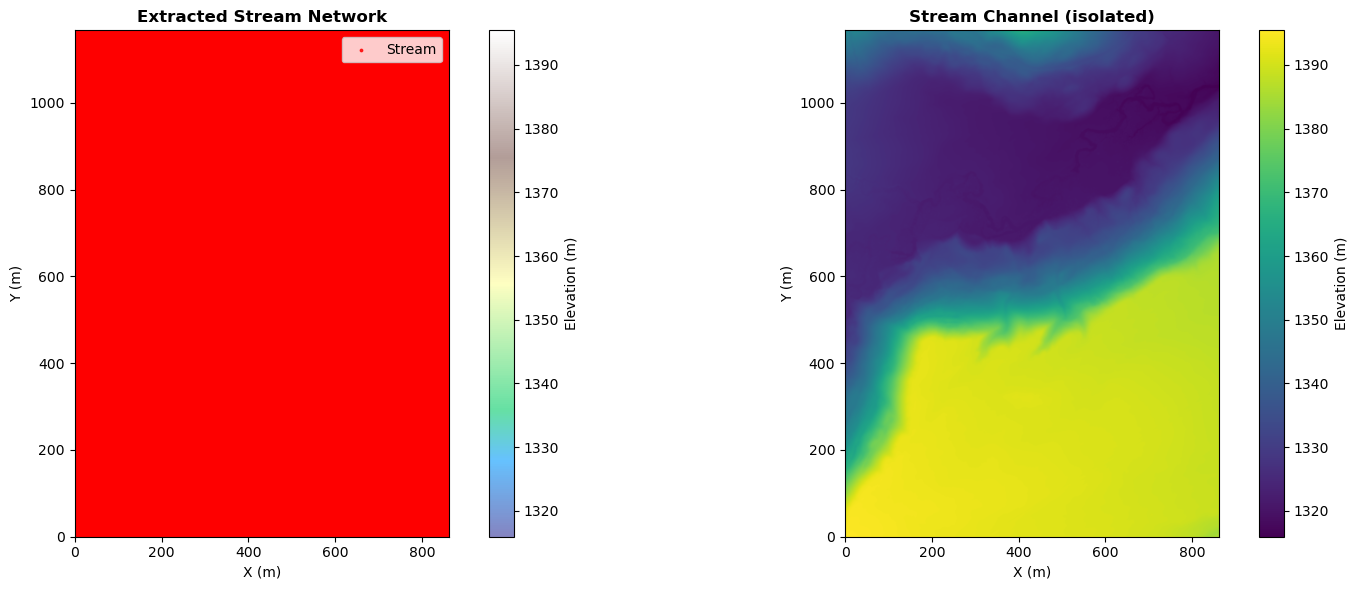

In [36]:
# ============================================================================
# STEP 5: Visualize Storm event
# ============================================================================

# --- Use the Landlab grid object ---
# mg: RasterModelGrid with 'topographic__elevation' and FlowAccumulator already run
elevation = mg.at_node['topographic__elevation']

# If you don't already have a stream mask, make one from drainage area (top 2%)
if 'stream_mask' not in globals():
    da = mg.at_node['drainage_area']
    # use only finite/core nodes to compute a robust threshold
    valid = np.isfinite(da)
    thresh = np.quantile(da[valid], 0.98)
    stream_mask = da >= thresh

# Convenience
nrows, ncols = mg.shape
dx = mg.dx if hasattr(mg, 'dx') else 1.0

# imshow expects pixel edges; approximate from node coords
xmin, xmax = mg.x_of_node.min(), mg.x_of_node.max()
ymin, ymax = mg.y_of_node.min(), mg.y_of_node.max()
extent = [xmin - dx/2, xmax + dx/2, ymin - dx/2, ymax + dx/2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: DEM + stream overlay ---
ax1 = axes[0]
im1 = ax1.imshow(
    elevation.reshape(nrows, ncols),
    origin='lower',
    cmap='terrain',
    extent=extent,
    alpha=0.6
)

stream_nodes = np.flatnonzero(stream_mask)
ax1.scatter(
    mg.x_of_node[stream_nodes],
    mg.y_of_node[stream_nodes],
    c='red', s=3, alpha=0.8, label='Stream'
)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('Extracted Stream Network', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
plt.colorbar(im1, ax=ax1, label='Elevation (m)')

# --- Right: Stream-only elevation (masked elsewhere as NaN) ---
ax2 = axes[1]
stream_elev = np.full(mg.number_of_nodes, np.nan, dtype=float)
stream_elev[stream_mask] = elevation[stream_mask]

im2 = ax2.imshow(
    stream_elev.reshape(nrows, ncols),
    origin='lower',
    cmap='viridis',
    extent=extent
)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Stream Channel (isolated)', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Elevation (m)')

plt.tight_layout()
# Save plot as PNG in the same directory as the CSV
plot_filename = f"{base}_stream_channel_isolated.png"
plot_path = os.path.join(path, plot_filename)
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
print(f"Saved plot to: {plot_path}")
plt.show()


In [37]:
# ============================================================================
# STEP 4B+6: Hydrodynamic features → write back to design CSV (+ optional stream CSV)
# ============================================================================

# --- safety/default ---
DEFAULT_THRESHOLD_PERCENTILE = 0.1
try:
    threshold_percentile
except NameError:
    threshold_percentile = DEFAULT_THRESHOLD_PERCENTILE

# --- 1) Node-wise slope from elevation ---
nrows, ncols = mg.shape
dx = float(getattr(mg, "dx", 1.0))

elev_nodes = mg.at_node["topographic__elevation"]
Z2 = elev_nodes.reshape(nrows, ncols)

# gradient-based slope magnitude
dZdy = np.gradient(Z2, dx, axis=0)
dZdx = np.gradient(Z2, dx, axis=1)
slope_nodes = np.hypot(dZdx, dZdy).ravel()

# --- 2) Drainage-area percentile + stream mask ---
drainage_area = mg.at_node["drainage_area"]
closed = (mg.status_at_node == mg.BC_NODE_IS_CLOSED)
valid = (~closed) & np.isfinite(drainage_area)

sorted_da = np.sort(drainage_area[valid])

def _percentile_rank(values, ref_sorted):
    # empirical CDF, right-inclusive
    idx = np.searchsorted(ref_sorted, values, side="right")
    return 100.0 * (idx / ref_sorted.size)

percentile_all = np.full(drainage_area.shape, np.nan, dtype=float)
percentile_all[valid] = _percentile_rank(drainage_area[valid], sorted_da)

cutoff = np.percentile(drainage_area[valid], threshold_percentile)
stream_mask = drainage_area >= cutoff

# --- 3) Width/depth (only for stream cells; NaN elsewhere) ---
width_all = np.full_like(drainage_area, np.nan, dtype=float)
depth_all = np.full_like(drainage_area, np.nan, dtype=float)

da_km2 = drainage_area / 1e6
width_all[stream_mask] = 0.4 * np.sqrt(np.clip(da_km2[stream_mask], 0, None))
depth_all[stream_mask] = 0.3 * np.power(np.clip(width_all[stream_mask], 0, None), 0.4)

# --- 4) Map node arrays → rows in your input DataFrame ---
node_id = (
    df_with_ixiy["iy"].astype(int).to_numpy() * ncols
    + df_with_ixiy["ix"].astype(int).to_numpy()
)

df_out = df_with_ixiy.copy()
df_out["drainage_area"] = drainage_area[node_id]
df_out["slope"]         = slope_nodes[node_id]
df_out["width_m"]       = width_all[node_id]
df_out["depth_m"]       = depth_all[node_id]
df_out["streamline"]    = np.where(stream_mask[node_id], "yes", "no")
df_out["percentile"]    = np.round(percentile_all[node_id], 2)  # 0–100

# --- 4b) Choose a REAL file path to save to (NOT the directory!) ---

# Use the cropped Chile DEM CSV as the base, and append "_hydro"
# Assumes `cropped_path` and `path` are defined from earlier cells.
base_cropped = os.path.splitext(os.path.basename(cropped_path))[0]
ext_cropped  = os.path.splitext(os.path.basename(cropped_path))[1]

out_path = os.path.join(path, f"{base_cropped}_hydro{ext_cropped}")

# drop helper indices and write CSV
df_out.drop(columns=["ix", "iy"], errors="ignore").to_csv(out_path, index=False)

print("✓ STEP 4B+6 complete.")
print(f"  Updated (hydro-annotated design CSV): {out_path}")
print(f"  Stream cutoff: {threshold_percentile}th percentile → DA ≥ {cutoff:.3f} m²")
print(f"  Stream cells:  {int(stream_mask.sum()):,} / {mg.number_of_nodes:,}")

# --- 5) (Optional) export streams-only CSV, like old Step 6 ---
try:
    # find an original design-area dataframe for offsets (if available)
    _design_df = None
    for cand in ("design_area", "df_design", "df"):
        if cand in globals():
            _design_df = globals()[cand]
            break

    x_offset = float(_design_df["x"].min()) if _design_df is not None else 0.0
    y_offset = float(_design_df["y"].min()) if _design_df is not None else 0.0

    stream_nodes = np.flatnonzero(stream_mask)
    stream_points = pd.DataFrame({
        "x": mg.x_of_node[stream_nodes] + x_offset,
        "y": mg.y_of_node[stream_nodes] + y_offset,
        "elevation":     elev_nodes[stream_nodes],
        "drainage_area": drainage_area[stream_nodes],
        "slope":         slope_nodes[stream_nodes],
        "width_m":       width_all[stream_nodes],
        "depth_m":       depth_all[stream_nodes],
        "percentile":    percentile_all[stream_nodes],
    })

    # Save a streams-only file next to the hydro CSV
    stream_csv = os.path.join(path, f"{base_cropped}_streams{ext_cropped}")
    stream_points.to_csv(stream_csv, index=False)
    print(f"  Also saved streams-only CSV: {stream_csv}")
except Exception as e:
    print(f"  (Optional streams-only export skipped: {e})")


✓ STEP 4B+6 complete.
  Updated (hydro-annotated design CSV): D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped_hydro.csv
  Stream cutoff: 0.1th percentile → DA ≥ 0.000 m²
  Stream cells:  1,007,984 / 1,007,984
  Also saved streams-only CSV: D:\Projects\BeaverBot\DEM\RumneyRanch\A_cropped_streams.csv


In [38]:
# ============================================================================
# STEP 7B: Align stream coords to design frame via box-to-box affine transform,
#          then nearest-neighbor join to update design_area
#
# UPDATE: writes drainage to DA["drainage_area_m2"] (and reads from SP["drainage_area_m2"]
#         if present, otherwise falls back to SP["drainage_area"])
# ============================================================================

import os
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# Define file paths
ext = ".csv"
cropped_file    = f"{base}_cropped_hydro{ext}"
streamline_file = f"{base}_streamline{ext}"

design_path = os.path.join(path, cropped_file)
stream_path = os.path.join(path, streamline_file)

# Load (prefer in-memory if present)
try:
    DA = design_area.copy()
except NameError:
    DA = pd.read_csv(design_path)

try:
    SP = stream_points.copy()
except NameError:
    SP = pd.read_csv(stream_path)

# Ensure numeric
for c in ["x", "y"]:
    if c not in DA.columns or c not in SP.columns:
        raise ValueError(f"Missing '{c}' column. DA cols: {list(DA.columns)} | SP cols: {list(SP.columns)}")
    DA[c] = pd.to_numeric(DA[c], errors="coerce")
    SP[c] = pd.to_numeric(SP[c], errors="coerce")

DA = DA.dropna(subset=["x", "y"]).reset_index(drop=True)
SP = SP.dropna(subset=["x", "y"]).reset_index(drop=True)

# --- Infer grid step on design grid for tolerance ---
def infer_step(vals: np.ndarray) -> float:
    u = np.sort(np.unique(vals))
    diffs = np.diff(u)
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        return np.nan
    r = np.round(diffs, 6)
    vals_u, counts = np.unique(r, return_counts=True)
    return float(vals_u[np.argmax(counts)])

dx = infer_step(DA["x"].values)
dy = infer_step(DA["y"].values)
candidates = [v for v in [dx, dy] if np.isfinite(v) and v > 0]
grid_step = min(candidates) if candidates else 1.0
tol = 0.51 * grid_step

# --- Compute box-to-box affine transform: (x', y') = (sx*x + tx, sy*y + ty)
xmin_d, xmax_d = float(DA["x"].min()), float(DA["x"].max())
ymin_d, ymax_d = float(DA["y"].min()), float(DA["y"].max())
xmin_s, xmax_s = float(SP["x"].min()), float(SP["x"].max())
ymin_s, ymax_s = float(SP["y"].min()), float(SP["y"].max())

sx = (xmax_d - xmin_d) / (xmax_s - xmin_s) if xmax_s != xmin_s else 1.0
sy = (ymax_d - ymin_d) / (ymax_s - ymin_s) if ymax_s != ymin_s else 1.0
tx = xmin_d - sx * xmin_s
ty = ymin_d - sy * ymin_s

# Transform stream coords into design frame
SP_aligned = SP.copy()
SP_aligned["x_aligned"] = sx * SP["x"] + tx
SP_aligned["y_aligned"] = sy * SP["y"] + ty

# --- Quick sanity check of alignment ---
def rng(a):
    return f"{a.min():.6f} .. {a.max():.6f}"

print("=== ALIGNMENT REPORT ===")
print(f"Design X range: {rng(DA['x'].values)}")
print(f"Stream  X range: {rng(SP['x'].values)}  -> Aligned: {rng(SP_aligned['x_aligned'].values)}")
print(f"Design Y range: {rng(DA['y'].values)}")
print(f"Stream  Y range: {rng(SP['y'].values)}  -> Aligned: {rng(SP_aligned['y_aligned'].values)}")
print(f"sx={sx:.9f}, tx={tx:.6f} | sy={sy:.9f}, ty={ty:.6f}")
print(f"Inferred grid_step={grid_step:.6f}, tol={tol:.6f}")

# --- Nearest-neighbor join in design frame ---
tree = cKDTree(DA[["x", "y"]].to_numpy())
dist, idx = tree.query(SP_aligned[["x_aligned", "y_aligned"]].to_numpy(), k=1)

match_mask = dist <= tol
SPm = SP.loc[match_mask].copy()
SPm_idx = idx[match_mask]

# --- Drainage column mapping (READ from SP, WRITE to DA["drainage_area_m2"]) ---
DRAIN_OUT = "drainage_area_m2"
if "drainage_area_m2" in SPm.columns:
    DRAIN_IN = "drainage_area_m2"
elif "drainage_area" in SPm.columns:
    DRAIN_IN = "drainage_area"
else:
    raise ValueError(f"Stream points missing drainage area column. Have: {list(SP.columns)}")

# If multiple aligned stream points map to the same design index, keep the one with max drainage
updated_rows = 0
skipped_due_to_water = 0

if not SPm.empty:
    tmp = SPm.copy()
    tmp["DA_index"] = SPm_idx

    # Keep max drainage per DA_index
    tmp.sort_values(DRAIN_IN, ascending=False, inplace=True)
    tmp = tmp.drop_duplicates(subset=["DA_index"], keep="first")

    # Ensure required columns exist on DA
    for col in [DRAIN_OUT, "slope", "width_m", "depth_m", "percentile"]:
        if col not in DA.columns:
            DA[col] = np.nan

    # Ensure required columns exist on tmp (safety)
    for col in ["slope", "width_m", "depth_m", "percentile"]:
        if col not in tmp.columns:
            tmp[col] = np.nan

    # Write metrics (NOTE drainage goes to drainage_area_m2)
    DA.loc[tmp["DA_index"], [DRAIN_OUT, "slope", "width_m", "depth_m", "percentile"]] = \
        tmp[[DRAIN_IN, "slope", "width_m", "depth_m", "percentile"]].to_numpy()

    updated_rows = len(tmp)

    # ---- Label update (ONLY upgrade land -> streamline; never touch water) ----
    if "streamline" not in DA.columns:
        DA["streamline"] = np.nan

    idx_arr = tmp["DA_index"].to_numpy()
    cur = DA.loc[idx_arr, "streamline"]
    cur_lc = cur.astype(str).str.strip().str.lower()

    is_water = cur_lc.eq("water")
    is_land  = cur_lc.eq("land")

    allow = is_land | cur.isna()
    safe_idx = idx_arr[allow.to_numpy()]
    skipped_due_to_water = int(is_water.sum())

    DA.loc[safe_idx, "streamline"] = "streamline"

# Save to disk
DA.to_csv(stream_path, index=False)

print("\n✓ Step 7B complete.")
print(f"  Stream points: {len(SP):,} | Matched within tol: {match_mask.sum():,} | Unique design rows updated: {updated_rows:,}")
print(f"  Skipped label upgrades due to water: {skipped_due_to_water:,}")
print(f"  Saved: {stream_path}")

# Peek at a few updated rows
if updated_rows > 0:
    sample_idx = DA.loc[DA["streamline"] == "streamline"].head(10).index
    cols_show = ["x","y","elevation","streamline",DRAIN_OUT,"slope","width_m","depth_m","percentile"]
    cols_show = [c for c in cols_show if c in DA.columns]
    display(DA.loc[sample_idx, cols_show])


=== ALIGNMENT REPORT ===
Design X range: 343786.499971 .. 344648.499971
Stream  X range: 343786.499971 .. 344648.499971  -> Aligned: 343786.499971 .. 344648.499971
Design Y range: 5420946.500015 .. 5422113.500015
Stream  Y range: 5420946.500015 .. 5422113.500015  -> Aligned: 5420946.500015 .. 5422113.500015
sx=1.000000000, tx=0.000000 | sy=1.000000000, ty=0.000000
Inferred grid_step=1.000000, tol=0.510000


C:\Users\AVAST3\AppData\Local\Temp\ipykernel_12408\2311332589.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'streamline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  DA.loc[safe_idx, "streamline"] = "streamline"



✓ Step 7B complete.
  Stream points: 1,007,984 | Matched within tol: 1,007,984 | Unique design rows updated: 1,007,984
  Skipped label upgrades due to water: 0
  Saved: D:\Projects\BeaverBot\DEM\RumneyRanch\A_streamline.csv


,x,y,elevation,streamline,drainage_area_m2,slope,width_m,depth_m,percentile
0,343786.499971,5.422114e+06,1353.1262,streamline,0.0,0.254168,0.0,0.0,0.286612
1,343787.499971,5.422114e+06,1352.9292,streamline,0.0,0.242460,0.0,0.0,0.286612
2,343788.499971,5.422114e+06,1352.7476,streamline,0.0,0.239762,0.0,0.0,0.286612
3,343789.499971,5.422114e+06,1352.5564,streamline,0.0,0.255349,0.0,0.0,0.286612
4,343790.499971,5.422114e+06,1352.3416,streamline,0.0,0.266279,0.0,0.0,0.286612
5,343791.499971,5.422114e+06,1352.1218,streamline,0.0,0.273219,0.0,0.0,0.286612
6,343792.499971,5.422114e+06,1351.8878,streamline,0.0,0.303928,0.0,0.0,0.286612
7,343793.499971,5.422114e+06,1351.5878,streamline,0.0,0.372495,0.0,0.0,0.286612
8,343794.499971,5.422114e+06,1351.1980,streamline,0.0,0.426769,0.0,0.0,0.286612
9,343795.499971,5.422114e+06,1350.7854,streamline,0.0,0.391103,0.0,0.0,0.286612


len(xs) = 863
range/dx = 862.0
largest x gaps: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Loaded: 1,007,984 rows
Grid: 1168 rows × 863 cols
Spacing: dx≈1.000 m, dy≈1.000 m
Cols with any data: 863 / 863
Rows with any data: 1168 / 1168


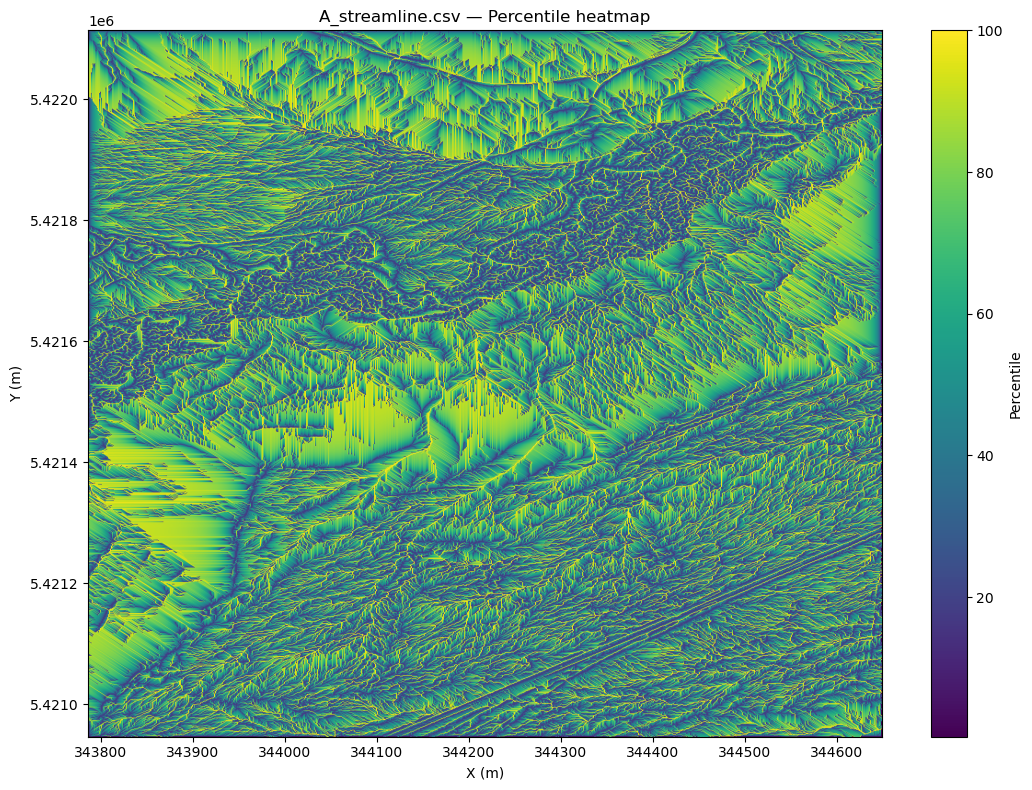

In [39]:
#====================================
#Visualize streamlines
#==============================

ext = ".csv"  # File extension
png = ".png"

streamline_file = f"{base}_streamline{ext}"
heat_file = f"{base}_streamline{png}"

stream_path = os.path.join(path, streamline_file)
csv_path = os.path.join(path, streamline_file)
plot_heatmap_path = os.path.join(path, heat_file)
# ----------------------------
# Load + clean
# ----------------------------
df = pd.read_csv(csv_path, low_memory=False)

# If the file has extra columns, keep only the ones we need
needed = ["x", "y", "percentile"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing columns: {missing}\nFound columns: {list(df.columns)}")

df = df[needed].copy()
df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["percentile"] = pd.to_numeric(df["percentile"], errors="coerce")
df = df.dropna(subset=["x", "y", "percentile"])

# ----------------------------
# Infer grid spacing (UTM meters)
# ----------------------------
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())
if len(xs) < 2 or len(ys) < 2:
    raise ValueError("Not enough unique x/y values to form a grid.")

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))

xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))

print("len(xs) =", len(xs))
print("range/dx =", (xs.max() - xs.min())/dx)
print("largest x gaps:", np.sort(np.diff(xs))[-10:])  # if you see a giant jump, that's it




x0, y0 = xs[0], ys[0]
nx, ny = len(xs), len(ys)

print(f"Loaded: {len(df):,} rows")
print(f"Grid: {ny} rows × {nx} cols")
print(f"Spacing: dx≈{dx:.3f} m, dy≈{dy:.3f} m")





# ----------------------------
# Map points to grid indices + aggregate
# ----------------------------
ix = np.rint((df["x"].to_numpy() - x0) / dx).astype(np.int64)
iy = np.rint((df["y"].to_numpy() - y0) / dy).astype(np.int64)
p  = df["percentile"].to_numpy(dtype=np.float64)

valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(p)
ix, iy, p = ix[valid], iy[valid], p[valid]

sum_p = np.zeros((ny, nx), dtype=np.float64)
cnt_p = np.zeros((ny, nx), dtype=np.uint32)

np.add.at(sum_p, (iy, ix), p)
np.add.at(cnt_p, (iy, ix), 1)

P = np.full((ny, nx), np.nan, dtype=np.float64)
mask = cnt_p > 0
P[mask] = sum_p[mask] / cnt_p[mask]

# Optional: if percentile is 0..1 and you want 0..100
# P *= 100.0

col_has = (cnt_p.sum(axis=0) > 0)
row_has = (cnt_p.sum(axis=1) > 0)

print("Cols with any data:", col_has.sum(), "/", col_has.size)
print("Rows with any data:", row_has.sum(), "/", row_has.size)

# Find first/last empty runs
empty_cols = np.where(~col_has)[0]
if empty_cols.size:
    print("Empty col index range(s):", empty_cols.min(), "to", empty_cols.max())



# ----------------------------
# Plot
# ----------------------------
extent = [xs.min() - dx/2, xs.max() + dx/2, ys.min() - dy/2, ys.max() + dy/2]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(P, origin="lower", extent=extent, aspect="auto")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percentile")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title(f"{base}_streamline.csv — Percentile heatmap")

plt.tight_layout()
plt.savefig(plot_heatmap_path, dpi=200, bbox_inches='tight')
plt.show()


# slope

In [40]:
import numpy as np
import pandas as pd
from pyproj import Transformer
from scipy.spatial import cKDTree

def utm_epsg_from_lonlat(lon, lat):
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 + zone) if lat >= 0 else (32700 + zone)

def add_xy_meters(df, x="x", y="y"):
    """
    If x/y look like lon/lat, project to UTM meters as x_m/y_m.
    If x/y already look projected, just copy to x_m/y_m.
    """
    df = df.copy()
    x_max = df[x].abs().max()
    y_max = df[y].abs().max()

    looks_geographic = (x_max <= 180) and (y_max <= 90)
    if looks_geographic:
        lon0 = float(df[x].median())
        lat0 = float(df[y].median())
        epsg = utm_epsg_from_lonlat(lon0, lat0)
        tf = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
        xm, ym = tf.transform(df[x].to_numpy(), df[y].to_numpy())
        df["x_m"] = xm
        df["y_m"] = ym
        df["proj_epsg"] = epsg
        print(f"Projected lon/lat -> UTM meters (EPSG:{epsg})")
    else:
        df["x_m"] = df[x].to_numpy()
        df["y_m"] = df[y].to_numpy()
        df["proj_epsg"] = np.nan
        print("x/y already look projected; using them as meters.")

    return df

def calculate_slope_grid_meters(df, x="x_m", y="y_m", z="elevation"):
    """
    Grid-based slope using np.gradient on a true raster grid (meters).
    Requires rows ≈ unique_x * unique_y (after rounding/snap, if needed).
    """
    df = df.copy()

    # snap to a grid if coordinates are *almost* gridded
    # (round to mm; adjust if your data is noisier)
    df[x] = np.round(df[x].astype(float), 3)
    df[y] = np.round(df[y].astype(float), 3)

    xs = np.sort(df[x].unique())
    ys = np.sort(df[y].unique())

    # infer spacing
    dx = float(np.median(np.diff(xs))) if len(xs) > 1 else 1.0
    dy = float(np.median(np.diff(ys))) if len(ys) > 1 else 1.0
    if dx <= 0 or dy <= 0:
        raise ValueError(f"Bad grid spacing after snap: dx={dx}, dy={dy}")

    expected = len(xs) * len(ys)
    if expected > len(df) * 1.2:
        raise ValueError(
            f"Not a full grid for pivot (expected {expected:,} cells from {len(xs):,}x{len(ys):,}, "
            f"but only {len(df):,} rows). Use kNN slope instead."
        )

    Z = df.pivot_table(index=y, columns=x, values=z, aggfunc="mean").reindex(index=ys, columns=xs).values

    dZ_dy, dZ_dx = np.gradient(Z, dy, dx)
    slope = np.degrees(np.arctan(np.sqrt(dZ_dx**2 + dZ_dy**2)))

    XX, YY = np.meshgrid(xs, ys)
    slope_flat = pd.DataFrame({x: XX.ravel(), y: YY.ravel(), "slope_degrees": slope.ravel()})
    out = df.merge(slope_flat, on=[x, y], how="left")
    out["slope_degrees"] = out["slope_degrees"].fillna(out["slope_degrees"].median())
    return out

def calculate_slope_knn_plane_meters(df, x="x_m", y="y_m", z="elevation", k=20):
    """
    Per-point slope from local best-fit plane using k nearest neighbors (meters).
    Works for scattered points.
    """
    df = df.copy()
    pts = df[[x, y]].to_numpy(dtype=float)
    zz  = df[z].to_numpy(dtype=float)

    tree = cKDTree(pts)
    _, idx = tree.query(pts, k=k)

    x0 = pts[:, 0][:, None]
    y0 = pts[:, 1][:, None]
    Xn = pts[idx, 0] - x0
    Yn = pts[idx, 1] - y0
    Zn = zz[idx] - zz[:, None]

    A00 = np.sum(Xn * Xn, axis=1)
    A01 = np.sum(Xn * Yn, axis=1)
    A11 = np.sum(Yn * Yn, axis=1)
    B0  = np.sum(Xn * Zn, axis=1)
    B1  = np.sum(Yn * Zn, axis=1)

    det = A00 * A11 - A01 * A01
    a = np.where(det != 0, (B0 * A11 - B1 * A01) / det, np.nan)
    b = np.where(det != 0, (B1 * A00 - B0 * A01) / det, np.nan)

    df["slope_degrees"] = np.degrees(np.arctan(np.sqrt(a*a + b*b)))
    df["slope_degrees"] = df["slope_degrees"].fillna(df["slope_degrees"].median())
    return df

def calculate_slope_auto(df):
    """
    Project to meters if needed, then:
    - use grid slope if it’s a real grid
    - otherwise fall back to kNN plane-fit in meters
    """
    df = add_xy_meters(df, x="x", y="y")

    # try grid method first
    try:
        return calculate_slope_grid_meters(df, x="x_m", y="y_m", z="elevation")
    except Exception as e:
        print("Grid slope not applicable -> using kNN slope. Reason:", e)
        return calculate_slope_knn_plane_meters(df, x="x_m", y="y_m", z="elevation", k=20)


In [41]:
def add_traversable_column(df, slope_col='slope_degrees', max_slope_deg=10.0, label_col='label'):
    """
    Add a boolean column indicating if agents can traverse this cell.

    Beavers can traverse cells if:
    - Slope is <= max_slope_deg, OR
    - The cell is labeled as 'water' (beavers can swim)

    Parameters
    ----------
    df : DataFrame
        Must contain slope column and label column
    slope_col : str
        Name of slope column
    max_slope_deg : float
        Maximum slope agents can traverse (degrees)
    label_col : str
        Name of label column that contains 'water' values

    Returns
    -------
    DataFrame
        With added 'traversable' column (True/False)
    """
    # Cell is traversable if slope is gentle enough OR if it's water
    df['traversable'] = (df[slope_col] <= max_slope_deg) | (df[label_col] == 'water')
    return df

In [42]:
# ============================================================================
# Define file paths
# ============================================================================
#os.path.join(path, file_name)
# Define file paths
ext = ".csv"  # File extension
streamline_file = f"{base}_streamline{ext}"
traversible = f"{base}_slopes{ext}"

stream_path = os.path.join(path, streamline_file)
slope_path = os.path.join(path, traversible)




In [43]:
df = pd.read_csv(stream_path, low_memory=False)

# numeric safety
for c in ["x","y","elevation"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["x","y","elevation"]).copy()

if "label" not in df.columns:
    df["label"] = "land"

print("Calculating slope...")
df = calculate_slope_auto(df)

max_slope_degrees = 50.0
df = add_traversable_column(df, max_slope_deg=max_slope_degrees, label_col="label")

df.to_csv(slope_path, index=False)
print("Saved:", slope_path)

print(df["slope_degrees"].describe())

Calculating slope...
x/y already look projected; using them as meters.
Saved: D:\Projects\BeaverBot\DEM\RumneyRanch\A_slopes.csv
count    1.007984e+06
mean     6.809969e+00
std      8.188986e+00
min      2.864789e-03
25%      7.976623e-01
50%      2.244558e+00
75%      1.144243e+01
max      4.923283e+01
Name: slope_degrees, dtype: float64


In [44]:
def calculate_slope_knn_plane(df, x="x", y="y", z="elevation", k=12):
    """
    Per-point slope from a local best-fit plane using k nearest neighbors.
    Works for scattered points / streamlines (no grid required).
    """
    df = df.copy()

    pts = df[[x, y]].to_numpy(dtype=float)
    zz  = df[z].to_numpy(dtype=float)

    tree = cKDTree(pts)
    d, idx = tree.query(pts, k=k)  # includes self as neighbor 0

    x0 = pts[:, 0][:, None]
    y0 = pts[:, 1][:, None]

    Xn = pts[idx, 0] - x0
    Yn = pts[idx, 1] - y0
    Zn = zz[idx] - zz[:, None]

    # Solve least squares for a,b in Zn ≈ a*Xn + b*Yn using normal equations
    A00 = np.sum(Xn * Xn, axis=1)
    A01 = np.sum(Xn * Yn, axis=1)
    A11 = np.sum(Yn * Yn, axis=1)
    B0  = np.sum(Xn * Zn, axis=1)
    B1  = np.sum(Yn * Zn, axis=1)

    det = A00 * A11 - A01 * A01
    a = np.where(det != 0, (B0 * A11 - B1 * A01) / det, np.nan)
    b = np.where(det != 0, (B1 * A00 - B0 * A01) / det, np.nan)

    slope = np.degrees(np.arctan(np.sqrt(a*a + b*b)))
    df["slope_degrees"] = slope

    # fill any numerical edge cases
    df["slope_degrees"] = df["slope_degrees"].fillna(df["slope_degrees"].median())
    return df

rows: 1,007,984 | unique x: 863 | unique y: 1,168 | unique_x*unique_y: 1,007,984
Calculating slope with kNN plane-fit (no pivot)...
Saved: D:\Projects\BeaverBot\DEM\RumneyRanch\A_slopes.csv

Slope statistics:
  Min slope: 0.00°
  Max slope: 46.95°
  Mean slope: 6.71°
  Median slope: 2.14°

Traversability (≤20.0°):
  Traversable cells: 909,870 (90.3%)
  Too steep: 98,114 (9.7%)


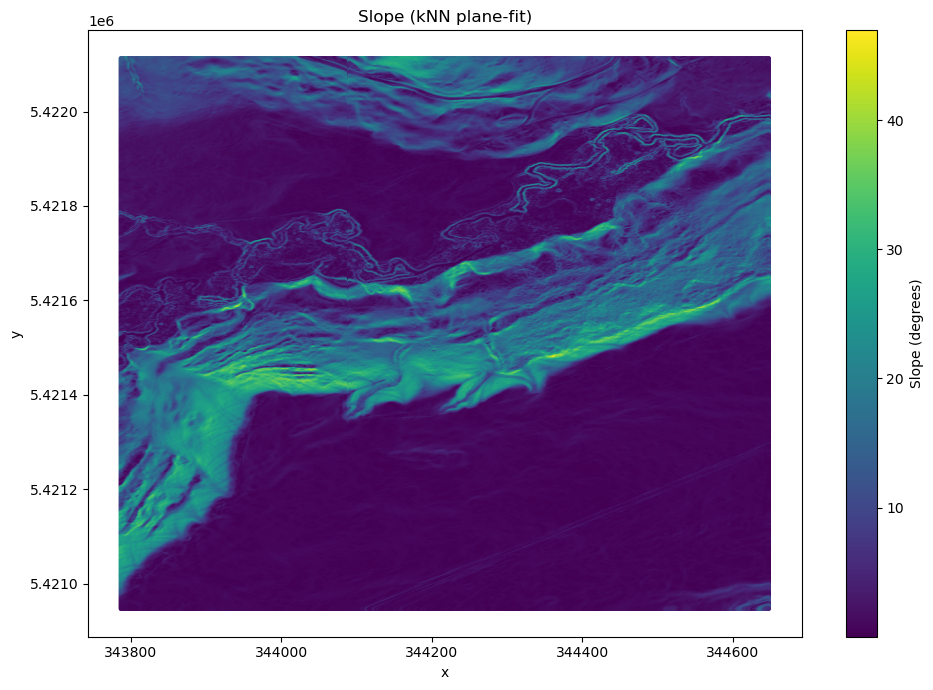

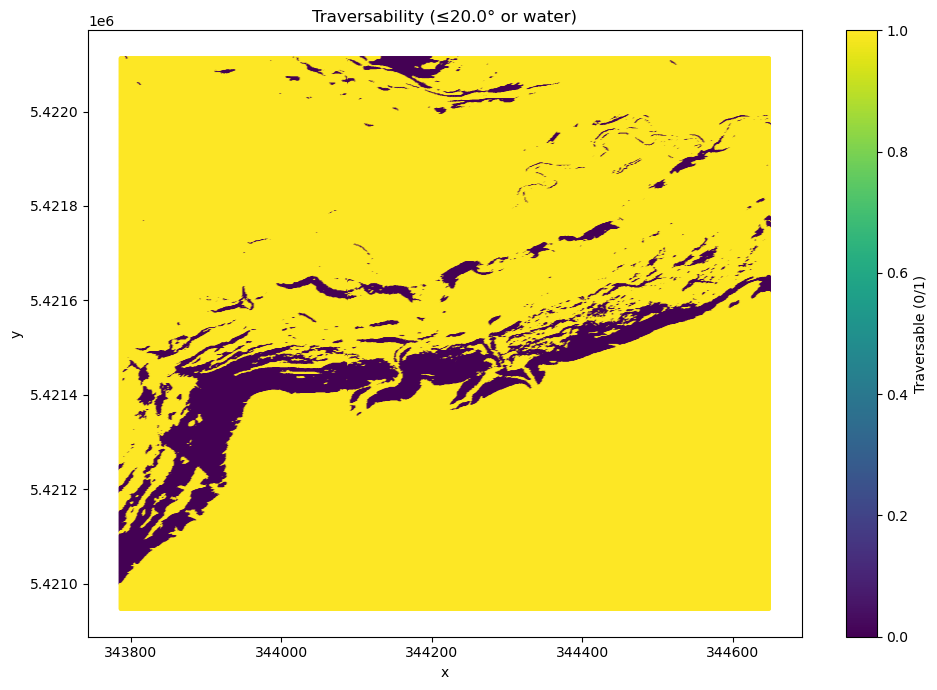

In [45]:
# ============================================================================
# Execute
# ============================================================================

df = pd.read_csv(stream_path, low_memory=False)

# Ensure numeric
for c in ["x", "y", "elevation"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["x", "y", "elevation"]).copy()

# Make sure label exists (so traversable logic works)
if "label" not in df.columns:
    df["label"] = "land"

# Print a grid sanity check
ux = df["x"].nunique()
uy = df["y"].nunique()
print(f"rows: {len(df):,} | unique x: {ux:,} | unique y: {uy:,} | unique_x*unique_y: {ux*uy:,}")

# ---- Slope (scattered-safe) ----
print("Calculating slope with kNN plane-fit (no pivot)...")
df = calculate_slope_knn_plane(df, k=12)

# ---- Traversability ----
max_slope_degrees = 20.0
df = add_traversable_column(df, max_slope_deg=max_slope_degrees, label_col="label")

# ---- Save ----
df.to_csv(slope_path, index=False)
print("Saved:", slope_path)

print(f"\nSlope statistics:")
print(f"  Min slope: {df['slope_degrees'].min():.2f}°")
print(f"  Max slope: {df['slope_degrees'].max():.2f}°")
print(f"  Mean slope: {df['slope_degrees'].mean():.2f}°")
print(f"  Median slope: {df['slope_degrees'].median():.2f}°")

print(f"\nTraversability (≤{max_slope_degrees}°):")
print(f"  Traversable cells: {df['traversable'].sum():,} ({df['traversable'].mean()*100:.1f}%)")
print(f"  Too steep: {(~df['traversable']).sum():,} ({(~df['traversable']).mean()*100:.1f}%)")

# ---- Plot (scatter, not pivot) ----
plt.figure(figsize=(10, 7))
sc = plt.scatter(df["x"], df["y"], c=df["slope_degrees"], s=2)
plt.colorbar(sc, label="Slope (degrees)")
plt.title("Slope (kNN plane-fit)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.savefig(os.path.join(path, f"{base}_slope_scatter.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
sc2 = plt.scatter(df["x"], df["y"], c=df["traversable"].astype(int), s=2)
plt.colorbar(sc2, label="Traversable (0/1)")
plt.title(f"Traversability (≤{max_slope_degrees}° or water)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

plt.savefig(os.path.join(path, f"{base}_traversable_scatter.png"), dpi=200, bbox_inches="tight")
plt.show()

## Overlay drainage on map

In [46]:
from pyproj import Geod


geod = Geod(ellps="WGS84")

with rasterio.open(out_tif) as src:
    # 1) Resolution in degrees/pixel (native for EPSG:4326)
    deg_x, deg_y = src.res  # (lon_deg_per_px, lat_deg_per_px) as positive magnitudes
    print("GeoTIFF resolution (deg/pixel):", deg_x, deg_y)

    # 2) Convert to meters/pixel at a few rows (top/mid/bottom) to show variation
    H, W = src.height, src.width
    sample_rows = [0, H//2, H-1]
    col = W // 2

    def meters_per_pixel_at(row, col):
        # rasterio.xy uses (row, col)
        lon0, lat0 = src.xy(row, col, offset="center")
        lon1, lat1 = src.xy(row, min(col+1, W-1), offset="center")   # right neighbor
        lon2, lat2 = src.xy(min(row+1, H-1), col, offset="center")   # down neighbor

        _, _, dx_m = geod.inv(lon0, lat0, lon1, lat1)  # meters east-west
        _, _, dy_m = geod.inv(lon0, lat0, lon2, lat2)  # meters north-south
        return abs(dx_m), abs(dy_m), (lon0, lat0)

    for r in sample_rows:
        dx_m, dy_m, (lonc, latc) = meters_per_pixel_at(r, col)
        print(f"Row {r:>6} at lat {latc:.6f}: ~{dx_m:.3f} m/px (x), ~{dy_m:.3f} m/px (y), area ~{dx_m*dy_m:.3f} m²/px")

    # 3) Single “headline” number (center of image)
    dx_m, dy_m, (lonc, latc) = meters_per_pixel_at(H//2, W//2)
    print("\nCenter-point meters/pixel:")
    print("  x:", dx_m, "m/px")
    print("  y:", dy_m, "m/px")
    print("  approx pixel area:", dx_m * dy_m, "m^2/px")


NameError: name 'out_tif' is not defined

In [ ]:
print("rows:", len(df))
print("unique x:", df["x"].nunique())
print("unique y:", df["y"].nunique())

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer, CRS

tif_path = dem_tif_path
csv_path = os.path.join(path, f"{base}_slopes.csv")

# EPSG = ... (you said you already set this earlier from metadata)
csv_crs = CRS.from_epsg(int(DATA_EPSG))

# Read a small sample of DEM points
probe = pd.read_csv(csv_path, nrows=50_000)

# Be forgiving about column names
cols = {c.lower(): c for c in probe.columns}
xcol = cols.get("x", None)
ycol = cols.get("y", None)
if xcol is None or ycol is None:
    raise ValueError(f"Couldn't find x/y columns. Columns are: {list(probe.columns)}")

x = pd.to_numeric(probe[xcol], errors="coerce").to_numpy()
y = pd.to_numeric(probe[ycol], errors="coerce").to_numpy()
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

with rasterio.open(tif_path) as src:
    tif_crs = CRS.from_user_input(src.crs)
    b = src.bounds

print("CSV CRS (from EPSG var):", csv_crs)
print("TIFF CRS:", tif_crs)
print("TIFF bounds (in TIFF CRS units):", b)

# Transform CSV points -> TIFF CRS so we can compare to src.bounds
if csv_crs == tif_crs:
    x_tif, y_tif = x, y
    print("No transform needed (CSV CRS == TIFF CRS).")
else:
    tf = Transformer.from_crs(csv_crs, tif_crs, always_xy=True)
    x_tif, y_tif = tf.transform(x, y)
    print(f"Transformed points: EPSG:{DATA_EPSG} -> {tif_crs.to_string()}")

inside = (x_tif >= b.left) & (x_tif <= b.right) & (y_tif >= b.bottom) & (y_tif <= b.top)
n_inside = int(np.sum(inside))

print(f"Inside count: {n_inside}/{len(x_tif)}")

# sanity peek
idx = np.where(inside)[0]
if len(idx) == 0:
    # Helpful diagnostics
    print("\n=== Diagnostics ===")
    print("CSV x range:", float(np.min(x)), "->", float(np.max(x)))
    print("CSV y range:", float(np.min(y)), "->", float(np.max(y)))
    print("TIFF x bounds:", b.left, "->", b.right)
    print("TIFF y bounds:", b.bottom, "->", b.top)

    raise RuntimeError(
        "No overlap found.\n"
        "Likely causes:\n"
        "  (1) EPSG is not actually the CRS for CSV x/y, or\n"
        "  (2) tif_path points to a different area than the CSV, or\n"
        "  (3) x/y columns are not map coordinates (e.g., pixel indices).\n"
    )

i0 = idx[0]
print("Example point inside (TIFF CRS):", x_tif[i0], y_tif[i0])

# Optional: also show that point in lon/lat for human sanity
to_ll = Transformer.from_crs(tif_crs, "EPSG:4326", always_xy=True)
lon0, lat0 = to_ll.transform(x_tif[i0], y_tif[i0])
print("Same point as lon/lat:", lon0, lat0)


In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer, CRS

tif_path = RGB_TIF = os.path.join(imagery_path, f"{sat_base}_sat_ON_DEM_GRID.tif")

csv_path = os.path.join(path, f"{base}_slopes.csv")
out_csv  = os.path.join(path, f"{base}_slopes_WITH_RGB.csv")

CSV_EPSG = DATA_EPSG  # <-- your CSV x/y CRS (what you called DEM_EPSG before)

chunksize = 200_000
first = True

with rasterio.open(tif_path) as src:
    raster_crs = CRS.from_user_input(src.crs)
    b = src.bounds

    print("Raster:", tif_path)
    print("  CRS:", raster_crs)
    print("  bounds:", b)
    print("  band count:", src.count)

    if src.count < 3:
        raise RuntimeError(
            f"GeoTIFF has {src.count} band(s), not RGB. "
            "Point tif_path at your 3-band satellite GeoTIFF (e.g., *_sat_ON_DEM_GRID.tif)."
        )

    csv_crs = CRS.from_epsg(int(CSV_EPSG))

    # Transform CSV coords -> raster CRS (only if needed)
    tf = None
    if csv_crs != raster_crs:
        tf = Transformer.from_crs(csv_crs, raster_crs, always_xy=True)
        print(f"  Transforming CSV coords: EPSG:{CSV_EPSG} -> {raster_crs.to_string()}")
    else:
        print("  No transform needed (CSV CRS == raster CRS).")

    for k, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize), start=1):
        cols = {c.lower(): c for c in chunk.columns}
        if "x" not in cols or "y" not in cols:
            raise ValueError(f"Chunk missing x/y columns. Found: {list(chunk.columns)}")

        x = pd.to_numeric(chunk[cols["x"]], errors="coerce").to_numpy()
        y = pd.to_numeric(chunk[cols["y"]], errors="coerce").to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)

        # coords in raster CRS
        xr = np.full(len(chunk), np.nan, dtype=float)
        yr = np.full(len(chunk), np.nan, dtype=float)

        if np.any(ok):
            if tf is None:
                xr[ok], yr[ok] = x[ok], y[ok]
            else:
                xr_ok, yr_ok = tf.transform(x[ok], y[ok])
                xr[ok], yr[ok] = xr_ok, yr_ok

        inside = ok & (xr >= b.left) & (xr <= b.right) & (yr >= b.bottom) & (yr <= b.top)

        R = np.full(len(chunk), np.nan, dtype=float)
        G = np.full(len(chunk), np.nan, dtype=float)
        B = np.full(len(chunk), np.nan, dtype=float)

        if np.any(inside):
            coords = np.column_stack([xr[inside], yr[inside]])  # raster CRS coords
            vals = np.vstack(list(src.sample(coords)))          # shape: (n, bands)

            R[inside] = vals[:, 0]
            G[inside] = vals[:, 1]
            B[inside] = vals[:, 2]

        chunk["img_R"] = R
        chunk["img_G"] = G
        chunk["img_B"] = B

        # helpful debug
        print(f"Chunk {k}: rows={len(chunk):,} ok={ok.sum():,} inside={inside.sum():,}")

        chunk.to_csv(out_csv, mode="w" if first else "a", header=first, index=False)
        first = False

print("Wrote:", out_csv)


In [ ]:
tif_path = os.path.join(imagery_path, f"{sat_base}_sat_ON_DEM_GRID.tif")
png_path = os.path.join(imagery_path, f"{sat_base}_sat_ON_DEM_GRID.png")
recon_png = os.path.join(imagery_path, f"{sat_base}_reconstructed_from_tif.png")


# -----------------------------
# 1) Reconstruct RGB from GeoTIFF
# -----------------------------
with rasterio.open(tif_path) as src:
    print("CRS:", src.crs)
    print("Width x Height:", src.width, "x", src.height)
    print("res (deg/pixel):", src.res)
    print("transform:\n", src.transform)

    # Read 3 bands (assumes bands 1..3 are R,G,B like you wrote)
    r = src.read(1)
    g = src.read(2)
    b = src.read(3)

    rgb = np.dstack([r, g, b])

# Ensure uint8 for PNG
if rgb.dtype != np.uint8:
    rgb8 = np.clip(rgb, 0, 255).astype(np.uint8)
else:
    rgb8 = rgb

Image.fromarray(rgb8).save(recon_png)
print("Saved reconstructed PNG:", recon_png)

# -----------------------------
# 2) Compare to your original cropped_rectified.png
# -----------------------------
orig = np.array(Image.open(png_path).convert("RGB"), dtype=np.uint8)

print("\nOriginal PNG shape:", orig.shape)
print("Reconstructed shape:", rgb8.shape)

if orig.shape != rgb8.shape:
    print("⚠️ Shapes differ -> something changed (different W/H).")
else:
    diff = np.abs(orig.astype(np.int16) - rgb8.astype(np.int16))
    print("Max abs channel diff:", diff.max())
    print("Mean abs channel diff:", diff.mean())
    print("Pixels with ANY channel diff:", np.count_nonzero(diff.max(axis=2)))
    print("Percent pixels changed:", 100 * np.count_nonzero(diff.max(axis=2)) / (orig.shape[0] * orig.shape[1]))


In [ ]:
from PIL import Image
from IPython.display import display

display(Image.open(recon_png))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = os.path.join(path, f"{base}_slopes_WITH_RGB.csv")



# --- user knobs ---
THRESH =25        # percentile threshold
ALPHA  = 0.2        # overlay transparency (0..1)
PCTL_COL = "percentile"   # change if your column name differs

df = pd.read_csv(csv_path)

# --- required cols ---
need = ["x","y","img_R","img_G","img_B", PCTL_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}\nColumns found: {list(df.columns)}")

# numeric safety
for c in ["x","y","img_R","img_G","img_B", PCTL_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with no RGB (optional but usually what you want)
df = df.dropna(subset=["x","y","img_R","img_G","img_B"]).copy()

# --- infer grid spacing & snap coords to grid to avoid float uniqueness issues ---
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))

x0 = xs.min()
y0 = ys.min()

# snap x,y onto grid
df["xg"] = x0 + np.round((df["x"] - x0) / dx) * dx
df["yg"] = y0 + np.round((df["y"] - y0) / dy) * dy

xg = np.sort(df["xg"].unique())
yg = np.sort(df["yg"].unique())

W = len(xg)
H = len(yg)

# row index: make top of image = max y (north-up)
y_max = yg.max()
df["col"] = np.searchsorted(xg, df["xg"].to_numpy())
df["row"] = np.round((y_max - df["yg"].to_numpy()) / dy).astype(int)

# --- build RGB + mask grids ---
rgb = np.zeros((H, W, 3), dtype=np.uint8)
mask = np.zeros((H, W), dtype=bool)

r = df["img_R"].clip(0,255).astype(np.uint8).to_numpy()
g = df["img_G"].clip(0,255).astype(np.uint8).to_numpy()
b = df["img_B"].clip(0,255).astype(np.uint8).to_numpy()
p = df[PCTL_COL].to_numpy()

rows = df["row"].to_numpy()
cols = df["col"].to_numpy()

rgb[rows, cols, 0] = r
rgb[rows, cols, 1] = g
rgb[rows, cols, 2] = b
mask[rows, cols]   = (p >= THRESH)

# --- plot with geospatial-ish axes (in your DEM CRS units) ---
x_min, x_max = xg.min(), xg.max()
y_min, y_max_plot = yg.min(), yg.max()
extent = [x_min, x_max, y_min, y_max_plot]

plt.figure(figsize=(12, 10))
plt.imshow(rgb, origin="upper", extent=extent)
plt.title(f"Satellite RGB with drainage overlay (percentile ≥ {THRESH})")
plt.xlabel("x")
plt.ylabel("y")

# overlay the threshold mask (colormap + alpha)
overlay = np.where(mask, 1.0, np.nan)  # nan = transparent
plt.imshow(overlay, origin="upper", extent=extent, alpha=ALPHA)

plt.show()


# Import USGS imagery

## Topo data

In [ ]:
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds, reproject, Resampling
from rasterio.transform import xy
from rasterio.features import rasterize
from rasterio.transform import from_origin

from pyproj import CRS, Transformer

# Image processing
from skimage.morphology import skeletonize, remove_small_objects, binary_opening, disk
from skimage.measure import label

# Graph traversal for skeleton -> ordered line
import networkx as nx
from shapely.geometry import LineString
import geopandas as gpd


In [ ]:
# -----------------------------
# Helpers
# -----------------------------
def bbox_from_corners(NW, SW, SE, NE):
    lons = [NW[0], SW[0], SE[0], NE[0]]
    lats = [NW[1], SW[1], SE[1], NE[1]]
    left, right = min(lons), max(lons)
    bottom, top = min(lats), max(lats)
    return left, bottom, right, top

def is_rgb(arr):
    return arr.ndim == 3 and arr.shape[0] >= 3

def extract_blue_stream_mask(rgb, b_min=120, blue_margin=30):
    """
    Very simple "blue ink" detector for topo maps.
    Tune b_min and blue_margin depending on your map.
    rgb is (bands, H, W) with bands order assumed RGB.
    """
    r = rgb[0].astype(np.int16)
    g = rgb[1].astype(np.int16)
    b = rgb[2].astype(np.int16)
    mask = (b >= b_min) & (b >= r + blue_margin) & (b >= g + blue_margin)
    return mask

def skeleton_to_linestrings(skel_bool, transform_affine, crs):
    """
    Convert a skeletonized binary raster into one or more LineStrings
    by building an 8-neighbor graph over skeleton pixels and extracting a main path
    for each connected component.
    """
    lbl = label(skel_bool, connectivity=2)
    lines = []

    # Precompute pixel coords for each component
    for comp_id in range(1, lbl.max() + 1):
        pts = np.column_stack(np.where(lbl == comp_id))  # rows, cols
        if pts.shape[0] < 10:
            continue

        # Build graph: node = (r,c), edges between 8-neighbors
        G = nx.Graph()
        ptset = set(map(tuple, pts))
        for r, c in ptset:
            G.add_node((r, c))
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    nb = (r + dr, c + dc)
                    if nb in ptset:
                        G.add_edge((r, c), nb)

        # Endpoints = degree 1 nodes
        deg = dict(G.degree())
        endpoints = [n for n, d in deg.items() if d == 1]

        # Choose a path to represent the centerline for this component
        if len(endpoints) >= 2:
            # Find "diameter" endpoints by double BFS on endpoints
            a = endpoints[0]
            lengths = nx.single_source_shortest_path_length(G, a)
            b = max(endpoints, key=lambda e: lengths.get(e, -1))

            lengths2 = nx.single_source_shortest_path_length(G, b)
            c = max(endpoints, key=lambda e: lengths2.get(e, -1))

            path_nodes = nx.shortest_path(G, b, c)
        else:
            # Loop / no endpoints: just take a DFS walk order
            start = next(iter(G.nodes))
            path_nodes = list(nx.dfs_preorder_nodes(G, source=start))

        # Convert nodes to world coords
        coords = []
        for r, c in path_nodes:
            x, y = xy(transform_affine, r, c, offset="center")
            coords.append((x, y))

        # Remove duplicates / tiny wiggles a bit
        if len(coords) >= 2:
            lines.append(LineString(coords))

    if not lines:
        return gpd.GeoDataFrame(geometry=[], crs=crs)

    return gpd.GeoDataFrame(geometry=lines, crs=crs)


In [ ]:
# -----------------------------
# 1) Locate topo GeoTIFF
# -----------------------------
topo_tif = Path(topo_path) / f"{topo_name}.tif"
if not topo_tif.exists():
    raise FileNotFoundError(f"Topo GeoTIFF not found: {topo_tif}")

out_dir = Path(topo_path) / "derived"
out_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# -----------------------------
# 2) Open slope raster (alignment target)
# -----------------------------
with rasterio.open(slope_path) as slope_ds:
    slope_crs = slope_ds.crs
    slope_transform = slope_ds.transform
    slope_shape = (slope_ds.height, slope_ds.width)

In [ ]:
# -----------------------------
# 3) Crop topo to AOI (given in lon/lat)
# -----------------------------
left, bottom, right, top = bbox_from_corners(NW, SW, SE, NE)

with rasterio.open(topo_tif) as topo_ds:
    topo_crs = topo_ds.crs
    if topo_crs is None:
        raise ValueError("Topo TIFF has no CRS. If you have a .prj file, we can assign it.")

    # Transform AOI bounds from EPSG:4326 -> topo CRS
    aoi_in_topo = transform_bounds("EPSG:4326", topo_crs, left, bottom, right, top, densify_pts=21)

    win = from_bounds(*aoi_in_topo, transform=topo_ds.transform)
    topo_crop = topo_ds.read(window=win)
    topo_crop_transform = rasterio.windows.transform(win, topo_ds.transform)

    crop_meta = topo_ds.meta.copy()
    crop_meta.update({
        "height": topo_crop.shape[1],
        "width": topo_crop.shape[2],
        "transform": topo_crop_transform
    })

crop_path = out_dir / f"{topo_name}_crop.tif"
with rasterio.open(crop_path, "w", **crop_meta) as dst:
    dst.write(topo_crop)

print("Wrote cropped topo:", crop_path)

In [ ]:
# -----------------------------
# 4) Reproject/align cropped topo to slope grid
# -----------------------------
with rasterio.open(crop_path) as src:
    src_data = src.read()
    src_crs = src.crs
    src_transform = src.transform

    aligned = np.zeros((src.count, slope_shape[0], slope_shape[1]), dtype=src_data.dtype)

    # If RGB imagery, keep nearest to preserve colors for stream extraction
    resampling = Resampling.nearest if is_rgb(src_data) else Resampling.bilinear

    for b in range(src.count):
        reproject(
            source=src_data[b],
            destination=aligned[b],
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=slope_transform,
            dst_crs=slope_crs,
            resampling=resampling
        )

aligned_path = out_dir / f"{topo_name}_aligned_to_slope.tif"
aligned_meta = crop_meta.copy()
aligned_meta.update({
    "crs": slope_crs,
    "transform": slope_transform,
    "height": slope_shape[0],
    "width": slope_shape[1],
})

with rasterio.open(aligned_path, "w", **aligned_meta) as dst:
    dst.write(aligned)

print("Wrote aligned topo:", aligned_path)


In [ ]:
# -----------------------------
# 5) Extract stream pixels (blue) -> skeleton -> centerlines
# -----------------------------
if not is_rgb(aligned):
    raise ValueError("Aligned topo is not RGB (needs at least 3 bands) for blue-stream extraction.")

blue = extract_blue_stream_mask(aligned, b_min=120, blue_margin=30)

# Clean up mask
blue = binary_opening(blue, footprint=disk(1))
blue = remove_small_objects(blue, min_size=50)

# Skeletonize
skel = skeletonize(blue)

# Vectorize skeleton to lines
gdf_lines = skeleton_to_linestrings(skel, slope_transform, slope_crs)

# Save as GeoJSON in slope CRS + also in lon/lat
stream_geojson_slope = out_dir / f"{topo_name}_streamlines_slopeCRS.geojson"
gdf_lines.to_file(stream_geojson_slope, driver="GeoJSON")
print("Wrote streamlines (slope CRS):", stream_geojson_slope)

gdf_ll = gdf_lines.to_crs("EPSG:4326")
stream_geojson_ll = out_dir / f"{topo_name}_streamlines_lonlat.geojson"
gdf_ll.to_file(stream_geojson_ll, driver="GeoJSON")
print("Wrote streamlines (lon/lat):", stream_geojson_ll)

In [ ]:
# -----------------------------
# 6) Rasterize streamlines to slope grid (mask) + update CSV
# -----------------------------
# Rasterize in slope CRS
stream_mask = rasterize(
    [(geom, 1) for geom in gdf_lines.geometry if geom is not None and not geom.is_empty],
    out_shape=slope_shape,
    transform=slope_transform,
    fill=0,
    dtype=np.uint8,
    all_touched=True
)

stream_mask_path = out_dir / f"{topo_name}_stream_mask_on_slope_grid.tif"
mask_meta = {
    "driver": "GTiff",
    "height": slope_shape[0],
    "width": slope_shape[1],
    "count": 1,
    "dtype": "uint8",
    "crs": slope_crs,
    "transform": slope_transform,
}
with rasterio.open(stream_mask_path, "w", **mask_meta) as dst:
    dst.write(stream_mask, 1)

print("Wrote stream mask:", stream_mask_path)

# Build a CSV for the slope grid with lon/lat + stream label
# (If you already have a slope CSV, we can merge instead—see note below.)
rows, cols = np.indices(slope_shape)
xs, ys = rasterio.transform.xy(slope_transform, rows, cols, offset="center")
xs = np.array(xs)
ys = np.array(ys)

# Convert slope CRS -> lon/lat
to_ll = Transformer.from_crs(CRS.from_user_input(slope_crs), CRS.from_epsg(4326), always_xy=True)
lons, lats = to_ll.transform(xs.ravel(), ys.ravel())

out_csv = out_dir / f"{topo_name}_slopegrid_with_stream_lonlat.csv"
df = pd.DataFrame({
    "x": xs.ravel(),
    "y": ys.ravel(),
    "lon": lons,
    "lat": lats,
    "stream": stream_mask.ravel().astype(np.uint8),
})
df.to_csv(out_csv, index=False)
print("Wrote CSV with stream labels:", out_csv)

## Sattelite imagery

In [ ]:
import os
import numpy as np
from PIL import Image

import rasterio
from rasterio.windows import from_bounds, Window
from rasterio.warp import reproject, Resampling
from pyproj import Transformer

# =========================
# INPUTS YOU ALREADY HAVE
# =========================
USGS_path = os.path.join(usgs_path, usgs_name)   # USGS imagery (GeoTIFF / georeferenced raster)
dem_tif_path = tif_path                            # your DEM GeoTIFF (e.g., EPSG:26913)

usgs_base = os.path.splitext(os.path.basename(USGS_path))[0]
out_png        = os.path.join(usgs_path, f"{usgs_base}_sat_ON_DEM_GRID.png")
out_crop_tif   = os.path.join(usgs_path, f"{usgs_base}_CROPPED.tif")
out_align_tif  = os.path.join(usgs_path, f"{usgs_base}_sat_ON_DEM_GRID.tif")


CORNERS_CRS = "EPSG:4326"  # change this if your corners are NOT lon/lat

# =========================
# READ DEM GRID DEFINITION
# =========================
with rasterio.open(dem_tif_path) as dem:
    DEM_CRS = dem.crs
    DEM_TRANSFORM = dem.transform
    DEM_W, DEM_H = dem.width, dem.height
    DEM_PROFILE = dem.profile.copy()

print("DEM CRS:", DEM_CRS)
print("DEM size (W,H):", DEM_W, DEM_H)
print("DEM res:", dem.res)

# =========================
# OPEN USGS IMAGE + CROP
# =========================
with rasterio.open(USGS_path) as src:
    SRC_CRS = src.crs
    SRC_TRANSFORM = src.transform

    if SRC_CRS is None:
        raise RuntimeError("USGS raster has no CRS. If it's a JPG/JIF, you may need a world file (.jgw/.tfw) + .prj.")

    print("USGS CRS:", SRC_CRS)
    print("USGS size (W,H):", src.width, src.height)

    # Transform crop corners into the USGS raster CRS
    corners = [NW, NE, SE, SW]
    lons = [c[0] for c in corners]
    lats = [c[1] for c in corners]

    to_src = Transformer.from_crs(CORNERS_CRS, SRC_CRS, always_xy=True)
    xs, ys = to_src.transform(lons, lats)

    left, right = min(xs), max(xs)
    bottom, top = min(ys), max(ys)

    # Build a read window from bounds
    win = from_bounds(left, bottom, right, top, transform=SRC_TRANSFORM)
    win = win.round_offsets().round_lengths()

    # Clip window to raster extent (prevents "out of range" reads)
    full = Window(0, 0, src.width, src.height)
    win = win.intersection(full)

    if win.width <= 0 or win.height <= 0:
        raise RuntimeError("Crop window is empty. Check CORNERS_CRS and the corner coordinates.")

    crop_transform = src.window_transform(win)

    # Read cropped data
    src_count = src.count
    use_count = min(src_count, 3)  # keep RGB if present
    cropped = src.read(indexes=list(range(1, use_count + 1)), window=win)

    # Save CROPPED GeoTIFF (in source CRS)
    crop_profile = src.profile.copy()
    crop_profile.update(
        height=cropped.shape[1],
        width=cropped.shape[2],
        transform=crop_transform,
        count=use_count
    )

    with rasterio.open(out_crop_tif, "w", **crop_profile) as dst:
        dst.write(cropped)

print("Saved CROPPED GeoTIFF:", out_crop_tif)
print("Driver:", src.driver)
print("CRS:", src.crs)
print("Transform:", src.transform)
print("Bounds:", src.bounds)

# =========================
# ALIGN CROPPED IMAGE TO DEM GRID
# =========================
with rasterio.open(out_crop_tif) as crop_src:
    src_crs = crop_src.crs
    src_transform = crop_src.transform
    src_dtype = crop_src.dtypes[0]
    src_nodata = crop_src.nodata
    count = crop_src.count

    aligned = np.zeros((count, DEM_H, DEM_W), dtype=np.dtype(src_dtype))

    for b in range(1, count + 1):
        reproject(
            source=rasterio.band(crop_src, b),
            destination=aligned[b - 1],
            src_transform=src_transform,
            src_crs=src_crs,
            src_nodata=src_nodata,
            dst_transform=DEM_TRANSFORM,
            dst_crs=DEM_CRS,
            dst_nodata=src_nodata,
            resampling=Resampling.bilinear
        )

# Write GeoTIFF exactly on DEM grid
profile = DEM_PROFILE.copy()
profile.update(
    driver="GTiff",
    count=aligned.shape[0],
    dtype=str(aligned.dtype),
    nodata=src_nodata
)

with rasterio.open(out_align_tif, "w", **profile) as dst:
    dst.write(aligned)

print("Saved aligned GeoTIFF:", out_align_tif)

# =========================
# QUICK PNG PREVIEW (optional)
# =========================
# If data isn't uint8, make a simple stretched preview
preview = aligned
if preview.dtype != np.uint8:
    p = preview.astype(np.float32)
    lo = np.nanpercentile(p, 2)
    hi = np.nanpercentile(p, 98)
    p = (p - lo) / (hi - lo + 1e-12)
    p = np.clip(p, 0, 1)
    preview = (255 * p).astype(np.uint8)

if preview.shape[0] == 1:
    rgb = np.repeat(preview[0][..., None], 3, axis=2)
else:
    rgb = np.stack([preview[0], preview[1], preview[2]], axis=2)

Image.fromarray(rgb).save(out_png)
print("Saved PNG preview:", out_png)



In [ ]:
os.path.join(usgs_path,usgs_base)

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer, CRS

tif_path = os.path.join(usgs_path, f"{usgs_base}_CROPPED.tif")
csv_path = os.path.join(path, f"{base}_slopes.csv")

# EPSG = <you already set this earlier from metadata>
csv_crs = CRS.from_epsg(int(DATA_EPSG))

# Read a small sample of points
probe = pd.read_csv(csv_path, nrows=50_000)

cols = {c.lower(): c for c in probe.columns}
xcol = cols.get("x"); ycol = cols.get("y")
if xcol is None or ycol is None:
    raise ValueError(f"Couldn't find x/y columns. Columns are: {list(probe.columns)}")

x = pd.to_numeric(probe[xcol], errors="coerce").to_numpy()
y = pd.to_numeric(probe[ycol], errors="coerce").to_numpy()
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

with rasterio.open(tif_path) as src:
    tif_crs = CRS.from_user_input(src.crs)
    b = src.bounds

print("CSV CRS:", csv_crs)
print("TIFF CRS:", tif_crs)
print("TIFF bounds (in TIFF CRS units):", b)

# Transform CSV points -> TIFF CRS (so they can be compared to src.bounds)
if csv_crs == tif_crs:
    x_tif, y_tif = x, y
    print("No transform needed (CSV CRS == TIFF CRS).")
else:
    tf = Transformer.from_crs(csv_crs, tif_crs, always_xy=True)
    x_tif, y_tif = tf.transform(x, y)
    print(f"Transformed points: {csv_crs.to_string()} -> {tif_crs.to_string()}")

inside = (x_tif >= b.left) & (x_tif <= b.right) & (y_tif >= b.bottom) & (y_tif <= b.top)
n_inside = int(inside.sum())

print(f"Inside count: {n_inside}/{len(x_tif)}")

if n_inside == 0:
    raise RuntimeError(
        "No overlap found.\n"
        "Most likely:\n"
        "  (1) EPSG (CSV CRS) is wrong for the CSV x/y, or\n"
        "  (2) you're comparing against the wrong TIFF, or\n"
        "  (3) x/y are pixel indices, not map coords.\n"
    )

i0 = np.where(inside)[0][0]
print("Example point inside (TIFF CRS):", x_tif[i0], y_tif[i0])


In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer, CRS

tif_path = os.path.join(usgs_path, f"{usgs_base}_CROPPED.tif")
csv_path = os.path.join(path, f"{base}_slopes.csv")

# Read a small sample of DEM/CSV points
probe = pd.read_csv(csv_path, nrows=50_000)

# Be forgiving about column names
cols = {c.lower(): c for c in probe.columns}
xcol = cols.get("x", None)
ycol = cols.get("y", None)
if xcol is None or ycol is None:
    raise ValueError(f"Couldn't find x/y columns. Columns are: {list(probe.columns)}")

x = pd.to_numeric(probe[xcol], errors="coerce").to_numpy()
y = pd.to_numeric(probe[ycol], errors="coerce").to_numpy()
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

# --- CRS objects ---
dem_crs = CRS.from_user_input(f"EPSG:{DATA_EPSG}")   # <-- your known CSV CRS

with rasterio.open(tif_path) as src:
    tif_crs = CRS.from_user_input(src.crs)
    b = src.bounds

print("CSV/DEM CRS (from EPSG var):", dem_crs)
print("TIFF CRS:", tif_crs)
print("TIFF bounds (in TIFF CRS units):", b)

# --- Transform CSV points into TIFF CRS (so we can compare to TIFF bounds) ---
if dem_crs == tif_crs:
    x_tif, y_tif = x, y
    print("No transform needed (CSV CRS == TIFF CRS).")
else:
    tr = Transformer.from_crs(dem_crs, tif_crs, always_xy=True)
    x_tif, y_tif = tr.transform(x, y)
    print(f"Transformed CSV points: {dem_crs.to_string()} -> {tif_crs.to_string()}")

# --- Overlap test in TIFF CRS coordinates ---
inside = (x_tif >= b.left) & (x_tif <= b.right) & (y_tif >= b.bottom) & (y_tif <= b.top)
n_inside = int(np.sum(inside))

print(f"Inside count: {n_inside}/{len(x_tif)}")

if n_inside == 0:
    # Helpful diagnostics
    print("\n=== Diagnostics ===")
    print("CSV x range:", float(np.min(x)), "->", float(np.max(x)))
    print("CSV y range:", float(np.min(y)), "->", float(np.max(y)))
    print("TIFF bound x:", b.left, "->", b.right)
    print("TIFF bound y:", b.bottom, "->", b.top)

    raise RuntimeError(
        "No overlap found.\n"
        "Most likely causes:\n"
        "  (1) EPSG (CSV CRS) is not actually correct for x/y in this CSV, or\n"
        "  (2) you’re using a different cropped TIFF than the CSV was derived from, or\n"
        "  (3) x/y columns are not map coordinates (e.g., row/col indices).\n"
    )

# sanity peek: show one point in TIFF CRS, and also as lon/lat if you want
i0 = np.where(inside)[0][0]
print("Example point inside (TIFF CRS):", x_tif[i0], y_tif[i0])

to_ll = Transformer.from_crs(tif_crs, "EPSG:4326", always_xy=True)
lon0, lat0 = to_ll.transform(x_tif[i0], y_tif[i0])
print("Same point as lon/lat:", lon0, lat0)


In [ ]:
DATA_EPSG 

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from pyproj import CRS, Transformer

tif_path = os.path.join(usgs_path, f"{usgs_base}_CROPPED.tif")
csv_path = os.path.join(path, f"{base}_slopes.csv")
out_csv  = os.path.join(path, f"{usgs_base}_slopes_WITH_RGB.csv")

CSV_EPSG = DATA_EPSG   # <-- THIS should be the CRS of the CSV x/y (the variable you said you already pulled)

chunksize = 200_000
first = True

with rasterio.open(tif_path) as src:
    raster_crs = CRS.from_user_input(src.crs)
    b = src.bounds
    nb = src.count

    print("Raster CRS:", raster_crs)
    print("Raster bounds:", b)
    print("Raster band count:", nb)

    if nb < 3:
        raise RuntimeError(
            f"This GeoTIFF has {nb} band(s), so it is not RGB.\n"
            "If you want img_R/img_G/img_B, point tif_path to a 3-band image GeoTIFF "
            "(e.g., your *_sat_ON_DEM_GRID.tif)."
        )

    csv_crs = CRS.from_epsg(int(CSV_EPSG))
    tf = None
    if csv_crs != raster_crs:
        tf = Transformer.from_crs(csv_crs, raster_crs, always_xy=True)
        print(f"Transforming CSV coords: EPSG:{CSV_EPSG} -> {raster_crs.to_string()}")
    else:
        print("No transform needed (CSV CRS == raster CRS).")

    for k, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize), start=1):
        cols = {c.lower(): c for c in chunk.columns}
        x = pd.to_numeric(chunk[cols["x"]], errors="coerce").to_numpy()
        y = pd.to_numeric(chunk[cols["y"]], errors="coerce").to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)

        xr = np.full(len(chunk), np.nan, dtype=float)
        yr = np.full(len(chunk), np.nan, dtype=float)

        if np.any(ok):
            if tf is None:
                xr[ok], yr[ok] = x[ok], y[ok]
            else:
                xr_ok, yr_ok = tf.transform(x[ok], y[ok])
                xr[ok], yr[ok] = xr_ok, yr_ok

        inside = ok & (xr >= b.left) & (xr <= b.right) & (yr >= b.bottom) & (yr <= b.top)

        R = np.full(len(chunk), np.nan, dtype=float)
        G = np.full(len(chunk), np.nan, dtype=float)
        B = np.full(len(chunk), np.nan, dtype=float)

        if np.any(inside):
            coords = np.column_stack([xr[inside], yr[inside]])  # IMPORTANT: raster CRS coords
            vals = np.vstack(list(src.sample(coords)))          # (n, nbands)
            R[inside] = vals[:, 0]
            G[inside] = vals[:, 1]
            B[inside] = vals[:, 2]

        chunk["img_R"] = R
        chunk["img_G"] = G
        chunk["img_B"] = B

        print(f"Chunk {k}: ok={ok.sum():,} inside={inside.sum():,}")

        chunk.to_csv(out_csv, mode="w" if first else "a", header=first, index=False)
        first = False

print("Wrote:", out_csv)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = os.path.join(path, f"{usgs_base}_slopes_WITH_RGB.csv")

# --- user knobs ---
THRESH =25        # percentile threshold
ALPHA  = 0.2        # overlay transparency (0..1)
PCTL_COL = "percentile"   # change if your column name differs

df = pd.read_csv(csv_path)

# --- required cols ---
need = ["x","y","img_R","img_G","img_B", PCTL_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}\nColumns found: {list(df.columns)}")

# numeric safety
for c in ["x","y","img_R","img_G","img_B", PCTL_COL]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with no RGB (optional but usually what you want)
df = df.dropna(subset=["x","y","img_R","img_G","img_B"]).copy()

# --- infer grid spacing & snap coords to grid to avoid float uniqueness issues ---
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))

x0 = xs.min()
y0 = ys.min()

# snap x,y onto grid
df["xg"] = x0 + np.round((df["x"] - x0) / dx) * dx
df["yg"] = y0 + np.round((df["y"] - y0) / dy) * dy

xg = np.sort(df["xg"].unique())
yg = np.sort(df["yg"].unique())

W = len(xg)
H = len(yg)

# row index: make top of image = max y (north-up)
y_max = yg.max()
df["col"] = np.searchsorted(xg, df["xg"].to_numpy())
df["row"] = np.round((y_max - df["yg"].to_numpy()) / dy).astype(int)

# --- build RGB + mask grids ---
rgb = np.zeros((H, W, 3), dtype=np.uint8)
mask = np.zeros((H, W), dtype=bool)

r = df["img_R"].clip(0,255).astype(np.uint8).to_numpy()
g = df["img_G"].clip(0,255).astype(np.uint8).to_numpy()
b = df["img_B"].clip(0,255).astype(np.uint8).to_numpy()
p = df[PCTL_COL].to_numpy()

rows = df["row"].to_numpy()
cols = df["col"].to_numpy()

rgb[rows, cols, 0] = r
rgb[rows, cols, 1] = g
rgb[rows, cols, 2] = b
mask[rows, cols]   = (p >= THRESH)

# --- plot with geospatial-ish axes (in your DEM CRS units) ---
x_min, x_max = xg.min(), xg.max()
y_min, y_max_plot = yg.min(), yg.max()
extent = [x_min, x_max, y_min, y_max_plot]

plt.figure(figsize=(12, 10))
plt.imshow(rgb, origin="upper", extent=extent)
plt.title(f"Satellite RGB with drainage overlay (percentile ≥ {THRESH})")
plt.xlabel("x")
plt.ylabel("y")

# overlay the threshold mask (colormap + alpha)
overlay = np.where(mask, 1.0, np.nan)  # nan = transparent
plt.imshow(overlay, origin="upper", extent=extent, alpha=ALPHA)

plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# =========================
# INPUT
# =========================
csv_path = os.path.join(path, f"{usgs_base}_slopes_WITH_RGB.csv")

# =========================
# USER KNOBS
# =========================
FLOW_COL  = "drainage_area_m2"   # <-- change to your flow/accum column name
USE_LOG10 = True                # log10 is usually nicer for accumulation-like fields
MIN_PCTL  = 70                  # hide low values; set None to show all
ALPHA_MAX = 0.9                # max overlay opacity (0..1)
GAMMA     = 0.7                 # alpha curve (smaller = brighter mid-values)
CMAP      = "inferno"           # overlay colormap

# =========================
# LOAD + VALIDATE
# =========================
df = pd.read_csv(csv_path)

need = ["x", "y", "img_R", "img_G", "img_B", FLOW_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns in CSV: {missing}\n"
        f"Columns found: {list(df.columns)}"
    )

for c in need:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=need).copy()

# =========================
# INFER GRID + SNAP TO GRID
# =========================
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())
if xs.size < 2 or ys.size < 2:
    raise ValueError("Not enough unique x/y values to infer a grid (need at least 2 unique x and y).")

dx = float(np.median(np.diff(xs)))
dy = float(np.median(np.diff(ys)))
if not (np.isfinite(dx) and np.isfinite(dy)) or dx == 0 or dy == 0:
    raise ValueError(f"Bad dx/dy inference. dx={dx}, dy={dy}")

x0 = float(xs.min())
y0 = float(ys.min())

df["xg"] = x0 + np.round((df["x"] - x0) / dx) * dx
df["yg"] = y0 + np.round((df["y"] - y0) / dy) * dy

xg = np.sort(df["xg"].unique())
yg = np.sort(df["yg"].unique())
W = int(len(xg))
H = int(len(yg))

y_max = float(yg.max())
x_min = float(xg.min())
y_min = float(yg.min())

# integer grid indices (more robust than searchsorted when floating jitter exists)
df["col"] = np.round((df["xg"] - x_min) / dx).astype(int)
df["row"] = np.round((y_max - df["yg"]) / dy).astype(int)

# drop anything that somehow landed out-of-bounds
inb = (df["col"].between(0, W - 1)) & (df["row"].between(0, H - 1))
df = df.loc[inb].copy()

rows = df["row"].to_numpy()
cols = df["col"].to_numpy()

# =========================
# BUILD RGB + FLOW GRIDS
# =========================
rgb = np.zeros((H, W, 3), dtype=np.uint8)
rgb[rows, cols, 0] = df["img_R"].clip(0, 255).astype(np.uint8).to_numpy()
rgb[rows, cols, 1] = df["img_G"].clip(0, 255).astype(np.uint8).to_numpy()
rgb[rows, cols, 2] = df["img_B"].clip(0, 255).astype(np.uint8).to_numpy()

flow = np.full((H, W), np.nan, dtype=float)
flow[rows, cols] = df[FLOW_COL].to_numpy()

# Optional: hide low values by percentile
if MIN_PCTL is not None:
    finite_flow = flow[np.isfinite(flow)]
    if finite_flow.size > 0:
        thr = np.nanpercentile(finite_flow, MIN_PCTL)
        flow = np.where(flow >= thr, flow, np.nan)

# Optional: log10 transform (only for positive finite values)
flow_plot = flow.copy()
if USE_LOG10:
    flow_plot = np.where(np.isfinite(flow_plot) & (flow_plot > 0), np.log10(flow_plot), np.nan)

# =========================
# PLOT
# =========================
# extent as pixel-edge bounds (so it lines up nicely)
extent = [x_min - dx/2, x_min + dx*(W-1) + dx/2, y_min - dy/2, y_min + dy*(H-1) + dy/2]

plt.figure(figsize=(12, 10))
plt.imshow(rgb, origin="upper", extent=extent, interpolation="nearest")
plt.title(f"USGS Satellite RGB with Flow overlay ({FLOW_COL})")
plt.xlabel("Easting / x")
plt.ylabel("Northing / y")

# =========================
# ROBUST ALPHA OVERLAY
# =========================
valid = flow_plot[np.isfinite(flow_plot)]
if valid.size == 0:
    print("No finite flow values to overlay (try lowering MIN_PCTL or disabling USE_LOG10). Showing RGB only.")
else:
    vmin = np.nanpercentile(valid, 5)
    vmax = np.nanpercentile(valid, 99)

    # handle degenerate/edge cases
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        vmin = float(np.nanmin(valid))
        vmax = float(np.nanmax(valid))
        if vmin == vmax:
            vmin -= 1e-9
            vmax += 1e-9

    # clip=True keeps normed values in [0,1] (prevents negative alpha bases)
    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

    A = np.zeros_like(flow_plot, dtype=float)
    m = np.isfinite(flow_plot)

    A[m] = norm(flow_plot[m])
    A = np.nan_to_num(A, nan=0.0, posinf=1.0, neginf=0.0)
    A = np.clip(A, 0.0, 1.0)

    A = (A ** GAMMA) * ALPHA_MAX
    A = np.clip(np.nan_to_num(A, nan=0.0), 0.0, 1.0)

    im = plt.imshow(
        flow_plot,
        origin="upper",
        extent=extent,
        cmap=CMAP,
        alpha=A,
        interpolation="nearest"
    )
    plt.colorbar(im, label=("log10(flow)" if USE_LOG10 else "flow"))

plt.show()


## Import NAIP Imagery

## Import drainage

# Validate resolution of DEM

In [ ]:
def estimate_grid_spacing(df, x_col="x", y_col="y"):
    x = pd.to_numeric(df[x_col], errors="coerce").dropna().to_numpy()
    y = pd.to_numeric(df[y_col], errors="coerce").dropna().to_numpy()

    xs = np.unique(x)
    ys = np.unique(y)
    xs.sort()
    ys.sort()

    if len(xs) < 2 or len(ys) < 2:
        raise ValueError("Not enough unique x/y values to estimate spacing.")

    dx = np.median(np.diff(xs))
    dy = np.median(np.diff(ys))

    return dx, dy, len(xs), len(ys)

# Example usage
df = pd.read_csv(csv_path, low_memory=False)
dx, dy, nx, ny = estimate_grid_spacing(df, x_col="x", y_col="y")

print(f"Grid dims: {ny} rows × {nx} cols")
print(f"Estimated spacing: dx={dx:.6f}, dy={dy:.6f}")

# Heuristic: if this is UTM (meters), dx/dy should be ~1.0
if abs(dx) > 1 and abs(dy) > 1:
    print("Looks like projected units (meters). Resolution is in meters.")
else:
    print("Looks like geographic degrees. Convert to meters using latitude if needed.")

import numpy as np
import pandas as pd

FT_PER_M = 3.280839895
M2_PER_ACRE = 4046.8564224



if "res_stats" not in globals() or res_stats is None:
    dx_safe = float(abs(dx)) if "dx" in globals() and dx is not None and np.isfinite(dx) else np.nan
    dy_safe = float(abs(dy)) if "dy" in globals() and dy is not None and np.isfinite(dy) else np.nan

    mean_m = np.nanmean([dx_safe, dy_safe])
    med_m  = np.nanmedian([dx_safe, dy_safe])

    res_stats = {
        "mean_meters": mean_m,
        "mean_feet": mean_m * FT_PER_M if np.isfinite(mean_m) else np.nan,
        "median_meters": med_m,
        "median_feet": med_m * FT_PER_M if np.isfinite(med_m) else np.nan,
    }


def estimate_grid_spacing(df, x_col="x", y_col="y"):
    x = pd.to_numeric(df[x_col], errors="coerce").dropna().to_numpy()
    y = pd.to_numeric(df[y_col], errors="coerce").dropna().to_numpy()

    xs = np.unique(x); xs.sort()
    ys = np.unique(y); ys.sort()

    if len(xs) < 2 or len(ys) < 2:
        raise ValueError("Not enough unique x/y values to estimate spacing.")

    dx = float(np.median(np.diff(xs)))
    dy = float(np.median(np.diff(ys)))

    return dx, dy, len(xs), len(ys), xs.min(), xs.max(), ys.min(), ys.max()

def _meters_per_degree(lat_deg: float):
    """Approx meters per degree lon/lat near a given latitude (good enough for small extents)."""
    lat = np.deg2rad(lat_deg)
    m_per_deg_lat = 111132.92 - 559.82*np.cos(2*lat) + 1.175*np.cos(4*lat) - 0.0023*np.cos(6*lat)
    m_per_deg_lon = 111412.84*np.cos(lat) - 93.5*np.cos(3*lat) + 0.118*np.cos(5*lat)
    return float(m_per_deg_lon), float(m_per_deg_lat)

def compute_area_dims_from_grid(xmin, xmax, ymin, ymax, dx, dy, assume_points_are_cell_centers=True, units="meters"):
    # range in coordinate units
    width_u  = float(xmax - xmin)
    height_u = float(ymax - ymin)

    # if points are cell centers, add one cell to get edge-to-edge span
    if assume_points_are_cell_centers:
        width_u  += abs(dx)
        height_u += abs(dy)

    if units == "degrees":
        lat_mid = 0.5 * (ymin + ymax)
        m_per_deg_lon, m_per_deg_lat = _meters_per_degree(lat_mid)
        width_m  = width_u  * m_per_deg_lon
        height_m = height_u * m_per_deg_lat
    else:
        width_m  = width_u
        height_m = height_u

    area_m2 = width_m * height_m
    return {
        "width_meters": width_m,
        "width_feet": width_m * FT_PER_M,
        "height_meters": height_m,
        "height_feet": height_m * FT_PER_M,
        "area_m2": area_m2,
        "area_km2": area_m2 / 1e6,
        "area_acres": area_m2 / M2_PER_ACRE,
    }

# =========================
# Example usage (drop-in)
# =========================
df = pd.read_csv(csv_path, low_memory=False)

dx, dy, nx, ny, xmin, xmax, ymin, ymax = estimate_grid_spacing(df, x_col="x", y_col="y")

print(f"Grid dims: {ny} rows × {nx} cols")
print(f"Estimated spacing: dx={dx:.6f}, dy={dy:.6f}")

# --- units heuristic ---
looks_like_degrees = (
    (-180 <= xmin <= 180) and (-180 <= xmax <= 180) and
    (-90  <= ymin <= 90)  and (-90  <= ymax <= 90)
)

units = "degrees" if looks_like_degrees else "meters"
print("Units guess:", "geographic degrees (lon/lat)" if units == "degrees" else "projected (meters)")

area_dims = compute_area_dims_from_grid(
    xmin, xmax, ymin, ymax,
    dx, dy,
    assume_points_are_cell_centers=True,   # set False if x/y are already pixel edges
    units=units
)

# --- your requested outputs ---
print(f"Width (meters):  {area_dims['width_meters']:.2f}")
print(f"Width (feet):    {area_dims['width_feet']:.2f}")
print(f"Height (meters): {area_dims['height_meters']:.2f}")
print(f"Height (feet):   {area_dims['height_feet']:.2f}")

print(f"DEM Area (m²):    {area_dims['area_m2']:.2f}")
print(f"DEM Area (km²):   {area_dims['area_km2']:.6f}")
print(f"DEM Area (acres): {area_dims['area_acres']:.2f}")


# Summary of site

In [ ]:
# ============================================================================
# DEM SUMMARY STATISTICS (CONSISTENT PRINT/FORMAT)
# ============================================================================
import os
import numpy as np
import pandas as pd
from datetime import datetime

def fmt(x, nd=2):
    """Safe numeric formatter -> string with nd decimals (handles NaN/None)."""
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "NaN"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def fmt_int(x):
    try:
        return f"{int(x)}"
    except Exception:
        return str(x)

def fmt_coord(pt):
    # expects (lon, lat) or (x, y) pair
    return f"({pt[0]:.6f}, {pt[1]:.6f})"

summary_data = {
    "Site Name": [str(base)],
    "CRS": [str(crs)],
    "DATA_EPSG": [fmt_int(DATA_EPSG)],
    "Resolution dx (map units)": [fmt(dx, 6)],
    "Resolution dy (map units)": [fmt(dy, 6)],

    "Calculated Mean Resolution (m)": [fmt(res_stats["mean_meters"], 2)],
    "Calculated Mean Resolution (ft)": [fmt(res_stats["mean_feet"], 2)],
    "Calculated Median Resolution (m)": [fmt(res_stats["median_meters"], 2)],
    "Calculated Median Resolution (ft)": [fmt(res_stats["median_feet"], 2)],

    "GPS NW Corner": [fmt_coord(NW)],
    "GPS SW Corner": [fmt_coord(SW)],
    "GPS SE Corner": [fmt_coord(SE)],
    "GPS NE Corner": [fmt_coord(NE)],

    "Projection Target EPSG": [fmt_int(DATA_EPSG)],

    "Width (m)": [fmt(area_dims["width_meters"], 2)],
    "Width (ft)": [fmt(area_dims["width_feet"], 2)],
    "Height (m)": [fmt(area_dims["height_meters"], 2)],
    "Height (ft)": [fmt(area_dims["height_feet"], 2)],

    "Max Elevation (m)": [fmt(np.nanmax(Z), 2)],
    "Min Elevation (m)": [fmt(np.nanmin(Z), 2)],
    "Mean Elevation (m)": [fmt(np.nanmean(Z), 2)],
    "Elevation Std Dev (m)": [fmt(np.nanstd(Z), 2)],

    "Mean Slope (deg)": [fmt(df["slope_degrees"].mean(), 2)],
    "Min Slope (deg)": [fmt(df["slope_degrees"].min(), 2)],
    "Max Slope (deg)": [fmt(df["slope_degrees"].max(), 2)],

    "Total Grid Cells": [fmt_int(Z.size)],
    "Grid Rows": [fmt_int(Z.shape[0])],
    "Grid Columns": [fmt_int(Z.shape[1])],

    "DEM Area (m^2)": [fmt(area_dims["area_m2"], 2)],
    "DEM Area (km^2)": [fmt(area_dims["area_km2"], 6)],
    "DEM Area (acres)": [fmt(area_dims["area_acres"], 2)],

    "Processing Date": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    "Source CSV": [str(file_name)],
    "Data Source": [str(data_source)],
    "FinalCSV": [os.path.join(path, f"{usgs_base}_slopes_WITH_RGB.csv")],
    "Source RBG sattelite imagery path":[os.path.join(usgs_path, f"{usgs_base}.tif")],
    "Source DEM imagery path":[os.path.join(path, tif_name)]
}

summary_df = pd.DataFrame(summary_data)

# Transpose for readability
summary_df_T = summary_df.T
summary_df_T.columns = ["Value"]
summary_df_T.index.name = "Parameter"

# Save summary CSV
summary_filename = f"{base}_site_dem_summary.csv"
summary_path = os.path.join(path, summary_filename)
summary_df_T.to_csv(summary_path)

# Consistent printout
banner = "=" * 72
print("\n" + banner)
print(str(base) + " DEM SUMMARY SAVED")
print(banner)
print(f"Saved summary to: {summary_path}")
print(banner)
print(summary_df_T.to_string())
print(banner)


In [ ]:
# Use segmentation model to identify water vs. land

In [ ]:
# Use trained model on vegetation to label vegetation type at the pixel scale

In [ ]:
# Using EEAGER MODEL to Identify where beavers are, beaver densities using dams as proxie for beave rpopulation density